# Amazon Product Co-Purchasing Network Analysis

**Analisis Jaringan Sosial - Kelompok 6**

📊 **Dataset**: Stanford Network Analysis Project (SNAP) - Amazon Product Co-Purchasing Network (March 2003)

🔗 **Google Colab**: [Open in Colab](https://colab.research.google.com/drive/1kx0L_GyVSyd4fVy1vJxFy5H2pQO2agtl?usp=sharing)

---

**Research Team**:
- Rafi Suwargana Putra
- Muhammad Iqbal Rasyid
- Marcel Epafroditus Hutahaean

**S-1 Informatika, Telkom University**

# ***-DATASET PREPARATION-***

In [1]:
# ENVIRONMENT SETUP
import os
import zipfile
import shutil
import pandas as pd
import numpy as np
import networkx as nx
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from itertools import islice
from collections import Counter, defaultdict
from google.colab import drive, data_table

!pip -q install --upgrade python-louvain
import community as community_louvain

print("LIBRARY VERSIONS")
print("=" * 70)
print(f"NumPy version\t: {np.__version__}\nPandas version\t: {pd.__version__}\nNetworkX ver.\t: {nx.__version__}\nMatplotlib ver.\t: {plt.matplotlib.__version__}\nSeaborn ver.\t: {sns.__version__}")

SHARED_FOLDER_NAME = "GOOGLE-COLAB-AJS"
DRIVE_DIR = f"/content/drive/MyDrive/{SHARED_FOLDER_NAME}"
WORK_DIR = "/content/amazon_work"

os.makedirs(WORK_DIR, exist_ok=True)

LIBRARY VERSIONS
NumPy version	: 2.0.2
Pandas version	: 2.2.2
NetworkX ver.	: 3.6.1
Matplotlib ver.	: 3.10.0
Seaborn ver.	: 0.13.2


In [2]:
# Mount Google Drive
drive.mount('/content/drive')

EDGELIST_TXT = os.path.join(DRIVE_DIR, "amazon0302_DVD_optimized_edgelist.txt")
META_CSV = os.path.join(DRIVE_DIR, "amazon0302_DVD_optimized.csv")

def require_file(path, label):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"File hasil pra-pemrosesan tidak ditemukan: {label}\n"
            f"Lokasi yang dicek: {path}\n"
            f"Pastikan Google Drive sudah ter-mount dan file tersimpan di DRIVE_DIR."
        )

def copy_to_workdir(src_path, work_dir):
    require_file(src_path, os.path.basename(src_path))
    dst_path = os.path.join(work_dir, os.path.basename(src_path))
    shutil.copy2(src_path, dst_path)
    return dst_path

def load_graph_from_edgelist(edgelist_path):
    require_file(edgelist_path, "amazon0302_DVD_optimized_edgelist.txt")
    return nx.read_edgelist(edgelist_path, create_using=nx.DiGraph(), nodetype=int)

def load_edges_with_meta(meta_csv_path):
    require_file(meta_csv_path, "amazon0302_DVD_optimized.csv")
    return pd.read_csv(meta_csv_path)

edgelist_local = copy_to_workdir(EDGELIST_TXT, WORK_DIR)
meta_local = copy_to_workdir(META_CSV, WORK_DIR)

G = load_graph_from_edgelist(edgelist_local)
df_final = load_edges_with_meta(meta_local)

print("Local files:")
print(" -", edgelist_local)
print(" -", meta_local)

print("\nEDGELIST (first 5 lines):")
with open(edgelist_local, "r", encoding="utf-8", errors="ignore") as f:
    for _ in range(5):
        line = f.readline()
        if not line:
            break
        print(line.rstrip("\n"))

print("\ndf_final.head():")
try:
    display(df_final.head())
except NameError:
    print(df_final.head().to_string(index=False))

Mounted at /content/drive
Local files:
 - /content/amazon_work/amazon0302_DVD_optimized_edgelist.txt
 - /content/amazon_work/amazon0302_DVD_optimized.csv

EDGELIST (first 5 lines):
1627 1640
1631 1632
1632 1631
1640 1627
1677 1678

df_final.head():


,ID,title,genre,ID_cp,title_cp,genre_cp
0,1627,Richard Strauss - Concerto for Horn,Musicals & Performing Arts,1640,I Love Lucy - Season One (Vol. 3),Television
1,1631,Arabian Nights,Action & Adventure,1632,Dragon Ball Z - Babidi - Battle Royal,Kids & Family
2,1632,Dragon Ball Z - Babidi - Battle Royal,Kids & Family,1631,Arabian Nights,Action & Adventure
3,1640,I Love Lucy - Season One (Vol. 3),Television,1627,Richard Strauss - Concerto for Horn,Musicals & Performing Arts
4,1677,Robert Louis Stevenson's St. Ives,Drama,1678,Just Married,Comedy


# ***-EDA & STATISTIC-***

## **Network Graph**

In [3]:
# COLOR MAP
palette = px.colors.qualitative.Light24

def compute_network_statistics(G):
    stats = {
        "Total Nodes": G.number_of_nodes(),
        "Total Edges": G.number_of_edges(),
        "Density": nx.density(G),
        "Avg In-Degree": sum(dict(G.in_degree()).values()) / G.number_of_nodes(),
        "Avg Out-Degree": sum(dict(G.out_degree()).values()) / G.number_of_nodes(),
        "Min Degree": min(dict(G.degree()).values()),
        "Max Degree": max(dict(G.degree()).values()),
        "Is Directed": G.is_directed(),
        "Weakly Connected": nx.is_weakly_connected(G),
        "Number of Weakly Connected Components": nx.number_weakly_connected_components(G),
    }

    largest_cc = max(nx.weakly_connected_components(G), key=len)
    stats["Largest Component Size"] = len(largest_cc)

    G_lcc = G.subgraph(largest_cc)
    stats["Diameter (Largest Component)"] = nx.diameter(G_lcc.to_undirected())

    return pd.DataFrame(stats.items(), columns=["Metric", "Value"])

def build_directed_graph_from_df(df_final):
    G = nx.DiGraph()
    G.add_edges_from(df_final[["ID", "ID_cp"]].itertuples(index=False, name=None))

    attrs = {}
    for _, r in df_final[["ID","title","genre"]].drop_duplicates("ID").iterrows():
        attrs[int(r["ID"])] = {"title": r["title"], "genre": r["genre"]}
    for _, r in df_final[["ID_cp","title_cp","genre_cp"]].drop_duplicates("ID_cp").iterrows():
        pid = int(r["ID_cp"])
        if pid not in attrs:
            attrs[pid] = {"title": r["title_cp"], "genre": r["genre_cp"]}

    nx.set_node_attributes(G, attrs)
    return G

def pick_viz_subgraph(G, max_nodes=999, seed=42):
    deg = dict(G.degree())
    if len(deg) <= max_nodes:
        return G.copy()
    top = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:max_nodes]
    nodes = [n for n, _ in top]
    return G.subgraph(nodes).copy()

G = build_directed_graph_from_df(df_final)
G_viz = pick_viz_subgraph(G, max_nodes=999, seed=42)

pos = nx.spring_layout(G_viz, seed=99, k=0.60, iterations=120, scale=2.5)

# Kalau node terlalu dekat → naikkan k (mis. 0.35 → 0.50).
# Kalau cluster terlalu jauh → turunkan k sedikit dan/atau turunkan scale (mis. 2.5 → 2.0).
# Kalau hasil “berantakan” → naikkan iterations.

node_list = list(G_viz.nodes())
x = np.array([pos[n][0] for n in node_list])
y = np.array([pos[n][1] for n in node_list])

in_deg = dict(G_viz.in_degree())
out_deg = dict(G_viz.out_degree())
tot_deg = dict(G_viz.degree())

genres = pd.Series([G_viz.nodes[n].get("genre", "Other") for n in node_list]).fillna("Other")
unique_genres = sorted(genres.unique().tolist())

unique_genres = sorted(unique_genres)
color_map = {g: palette[i] for i, g in enumerate(unique_genres)}

size_raw = np.array([tot_deg.get(n, 0) for n in node_list], dtype=float)
size = 6 + 18 * (size_raw - size_raw.min()) / (size_raw.max() - size_raw.min() + 1e-9)

hover = []
for n in node_list:
    hover.append(
        f"ID: {n}"
        f"<br>title: {G_viz.nodes[n].get('title','')}"
        f"<br>genre: {G_viz.nodes[n].get('genre','')}"
        f"<br>in-degree: {in_deg.get(n,0)}"
        f"<br>out-degree: {out_deg.get(n,0)}"
        f"<br>total-degree: {tot_deg.get(n,0)}"
    )

xe, ye = [], []
edges_list = list(G_viz.edges())
for u, v in edges_list:
    xe += [pos[u][0], pos[v][0], None]
    ye += [pos[u][1], pos[v][1], None]

edge_trace = go.Scatter(
    x=xe, y=ye,
    mode="lines",
    line=dict(width=0.6),
    hoverinfo="skip",
    name="Edges"
)

fig = go.Figure()
fig.add_trace(edge_trace)

for g in unique_genres:
    idx = (genres.values == g)
    fig.add_trace(
        go.Scatter(
            x=x[idx],
            y=y[idx],
            mode="markers",
            name=g,
            marker=dict(size=size[idx], color=color_map[g], line=dict(width=0.4)),
            text=np.array(hover, dtype=object)[idx],
            hoverinfo="text"
        )
    )

MAX_ARROWS = 250
arrow_edges = edges_list[:MAX_ARROWS]

annotations = []
for u, v in arrow_edges:
    x0, y0 = pos[u][0], pos[u][1]
    x1, y1 = pos[v][0], pos[v][1]
    annotations.append(
        dict(
            x=x1, y=y1, ax=x0, ay=y0,
            xref="x", yref="y", axref="x", ayref="y",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=1,
            opacity=0.75,
            text=""
        )
    )

In [4]:
fig.update_layout(
    title=f"Interactive Co-Purchase Network (Directed) — Spring Layout (nodes={G_viz.number_of_nodes():,}, edges={G_viz.number_of_edges():,})",
    height=600,
    margin=dict(l=10, r=10, t=70, b=10),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    legend=dict(title="Genre", itemsizing="constant"),
    annotations=annotations
)
fig.show()

compute_network_statistics(G)

,Metric,Value
0,Total Nodes,503
1,Total Edges,922
2,Density,0.003651
3,Avg In-Degree,1.833002
4,Avg Out-Degree,1.833002
5,Min Degree,1
6,Max Degree,11
7,Is Directed,True
8,Weakly Connected,False
9,Number of Weakly Connected Components,162


In [5]:
def plot_scatter_in_out(df_final, title_trunc=60, max_titles_in_hover=25, sensitivity="log", colorscale="Turbo"):
    def _trunc(s, n=60):
        s = "" if s is None else str(s)
        return (s[: n - 1] + "…") if len(s) > n else s

    meta = {}
    a = df_final[["ID", "title", "genre"]].drop_duplicates("ID")
    for _, r in a.iterrows():
        pid = int(r["ID"])
        meta[pid] = {"title": r["title"], "genre": r["genre"]}

    b = df_final[["ID_cp", "title_cp", "genre_cp"]].drop_duplicates("ID_cp")
    for _, r in b.iterrows():
        pid = int(r["ID_cp"])
        if pid not in meta:
            meta[pid] = {"title": r["title_cp"], "genre": r["genre_cp"]}

    in_deg = {}
    out_deg = {}
    nodes = set()

    for u, v in df_final[["ID", "ID_cp"]].itertuples(index=False, name=None):
        u = int(u); v = int(v)
        nodes.add(u); nodes.add(v)
        out_deg[u] = out_deg.get(u, 0) + 1
        in_deg[v] = in_deg.get(v, 0) + 1

    for n in nodes:
        in_deg.setdefault(n, 0)
        out_deg.setdefault(n, 0)

    coord_titles = {}
    coord_counts = {}
    for n in nodes:
        x = out_deg[n]
        y = in_deg[n]
        t = _trunc(meta.get(n, {}).get("title", ""), title_trunc)

        coord_titles.setdefault((x, y), []).append(t)
        coord_counts[(x, y)] = coord_counts.get((x, y), 0) + 1

    for k in coord_titles:
        coord_titles[k].sort()

    xs, ys, sizes, colors, hovers = [], [], [], [], []

    labels = []
    for n in nodes:
        x = out_deg[n]
        y = in_deg[n]
        total = x + y
        labels.append(str(coord_counts[(x, y)]))

        cnt_titles = coord_counts[(x, y)]
        if sensitivity == "log":
            col_val = np.log1p(cnt_titles)
        else:
            col_val = cnt_titles

        titles = coord_titles[(x, y)]
        shown = titles[:max_titles_in_hover]
        more = len(titles) - len(shown)

        titles_html = "<br>".join([f"- {t}" for t in shown])
        if more > 0:
            titles_html += f"<br>- … (+{more} more)"

        xs.append(x)
        ys.append(y)
        sizes.append(14 + 3 * total)  # hardcode boost supaya degree kecil tetap kelihatan
        colors.append(col_val)
        hovers.append(
            f"out-degree (x): {x}"
            f"<br>in-degree (y): {y}"
            f"<br>total-degree: {total}"
            f"<br><b>titles at (x={x}, y={y}): {cnt_titles}</b>"
            f"<br><br>{titles_html}"
        )

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=xs, y=ys,
        mode="markers+text",  # Changed from "markers" to include text
        text=labels,          # Set the visible text on the plot to the count
        textposition="middle center", # Position text in center of marker
        textfont=dict(
            family="Arial",
            size=10,          # Adjust size as needed so it fits inside
            color="white",
            shadow="auto"
        ),
        marker=dict(
            size=sizes,
            color=colors,
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(
                title=("log1p(#titles)" if sensitivity == "log" else "#titles"),
                len=0.8
            ),
            line=dict(width=0.4),
            opacity=0.85
        ),
        hovertext=hovers,
        hoverinfo="text",
        showlegend=False
    ))

    fig.update_layout(
        title="Products Scatter — In-Degree vs Out-Degree (Full Graph) | color = #titles per (x,y)",
        height=760,
        margin=dict(l=10, r=10, t=70, b=10),
        xaxis=dict(title="Out-Degree (Purchased FROM count)"),
        yaxis=dict(title="In-Degree (Co-Purchased TO count)")
    )
    fig.show()
plot_scatter_in_out(df_final, sensitivity="log", colorscale="Turbo")

## **Genre**

In [6]:
def print_genre_distribution(df, col_from="genre", col_to="genre_cp", title="GENRE DISTRIBUTION (AFTER)"):
    print(title)
    print("=" * 70)

    vc_from = df[col_from].value_counts()
    vc_to = df[col_to].value_counts()

    all_genres = sorted(set(vc_from.index) | set(vc_to.index))

    unc = int(vc_from.get("UNCATEGORIZED", 0))
    print(f"UNCATEGORIZED: {unc:,}\n")

    total_all = int(vc_from.sum() + vc_to.sum())

    print("genre")
    for g in all_genres:
        from_cnt = int(vc_from.get(g, 0))
        to_cnt = int(vc_to.get(g, 0))
        total = from_cnt + to_cnt
        if total > 0:
            pct = (total / total_all * 100) if total_all else 0.0
            print(f"{g:30s} {total:5d} ({from_cnt}+{to_cnt})\t\t{pct:6.2f}%")

    print()

def plot_genre_summary(df_final, top_k=10, palette_name="Light24"):
    vc_from = df_final["genre"].value_counts()
    vc_to = df_final["genre_cp"].value_counts()
    vc_total = vc_from.add(vc_to, fill_value=0).sort_values(ascending=False)

    df_pie = vc_total.reset_index()
    df_pie.columns = ["genre", "count"]
    df_pie["count"] = df_pie["count"].astype(int)
    df_pie = df_pie.sort_values("genre", ascending=True).reset_index(drop=True)

    palette = getattr(px.colors.qualitative, palette_name)
    colors = [palette[i % len(palette)] for i in range(len(df_pie))]

    fig_pie = go.Figure(
        data=[
            go.Pie(
                labels=df_pie["genre"],
                values=df_pie["count"],
                marker=dict(colors=colors),
                textinfo="label+percent+value",
                hovertemplate="genre=%{label}<br>count=%{value:,}<br>percent=%{percent}<extra></extra>"
            )
        ]
    )
    fig_pie.update_layout(title="Genre Distribution (TOTAL) — Count & Percentage", height=650)
    fig_pie.show()

    top_genres = vc_total.head(top_k).index.tolist()
    df_gen = pd.DataFrame({
        "genre": top_genres,
        "from_cnt": [int(vc_from.get(g, 0)) for g in top_genres],
        "to_cnt": [int(vc_to.get(g, 0)) for g in top_genres],
    })
    df_gen["total"] = df_gen["from_cnt"] + df_gen["to_cnt"]
    df_gen = df_gen.sort_values("total", ascending=False)

    fig = go.Figure()

    fig.add_trace(go.Bar(
        y=df_gen["genre"],
        x=df_gen["from_cnt"],
        name="Purchased (FROM)",
        orientation="h",
        customdata=np.stack([df_gen["to_cnt"], df_gen["total"]], axis=1),
        hovertemplate="genre=%{y}<br>from=%{x:,}<br>to=%{customdata[0]:,}<br>total=%{customdata[1]:,}<extra></extra>"
    ))

    fig.add_trace(go.Bar(
        y=df_gen["genre"],
        x=df_gen["to_cnt"],
        name="Co-Purchased (TO)",
        orientation="h",
        text=[f"{t:,}" for t in df_gen["total"]],
        textposition="outside",
        cliponaxis=False,
        customdata=np.stack([df_gen["from_cnt"], df_gen["total"]], axis=1),
        hovertemplate="genre=%{y}<br>to=%{x:,}<br>from=%{customdata[0]:,}<br>total=%{customdata[1]:,}<extra></extra>"
    ))

    fig.update_layout(
        title="Top 10 Genres — Stacked (Sorted by TOTAL DESC)",
        barmode="stack",
        height=540,
        margin=dict(l=10, r=90, t=70, b=10),
        legend=dict(title="Component"),
        xaxis=dict(title="Count")
    )
    fig.update_yaxes(autorange="reversed")
    fig.show()

    print_genre_distribution(df_final, col_from="genre", col_to="genre_cp", title="GENRE STATISTIC DISTRIBUTION")

plot_genre_summary(df_final, top_k=10, palette_name="Light24")

GENRE STATISTIC DISTRIBUTION
UNCATEGORIZED: 0

genre
Action & Adventure               143 (73+70)		  7.75%
Adult                             21 (10+11)		  1.14%
Animation                         76 (41+35)		  4.12%
Art & International               10 (6+4)		  0.54%
Classics                          82 (37+45)		  4.45%
Comedy                           246 (119+127)		 13.34%
Documentary                       94 (46+48)		  5.10%
Drama                            289 (140+149)		 15.67%
General                           10 (5+5)		  0.54%
Horror                           127 (67+60)		  6.89%
Kids & Family                    126 (61+65)		  6.83%
Military & War                    13 (7+6)		  0.70%
Music Video & Concerts           165 (84+81)		  8.95%
Musicals & Performing Arts        60 (30+30)		  3.25%
Mystery & Suspense               129 (65+64)		  7.00%
Religion & Spirituality            6 (3+3)		  0.33%
Science Fiction & Fantasy         84 (44+40)		  4.56%
Sports                           

# ***-CENTRALITY-***

In [7]:
def get_node_info(G, node_id):
    """Helper to get title and genre for a given node_id."""
    return {
        "title": G.nodes[node_id].get('title', 'N/A'),
        "genre": G.nodes[node_id].get('genre', 'N/A')
    }

def display_top_nodes(centrality_dict, G, title, n=10):
    """
    Displays the top N nodes based on a given centrality measure.
    Assumes G has 'title' and 'genre' attributes for nodes.
    """
    sorted_nodes = sorted(centrality_dict.items(), key=lambda item: item[1], reverse=True)
    data = []
    for node_id, score in islice(sorted_nodes, n):
        info = get_node_info(G, node_id)
        data.append({
            "ID": node_id,
            "Title": info["title"],
            "Genre": info["genre"],
            "Score": score
        })
    df_result = pd.DataFrame(data)
    print(f"\nTOP {n} NODES BY {title}")
    print("=" * 70)
    display(data_table.DataTable(df_result, include_index=False, num_rows_per_page=n))

def plot_centrality_distribution(centrality_dict, title, x_axis_label, color_discrete_sequence=None):
    """
    Plots the distribution of centrality scores.
    """
    df_scores = pd.DataFrame(list(centrality_dict.items()), columns=["ID", "Score"])
    fig = px.histogram(df_scores, x="Score", nbins=50,
                       title=f"Distribution of {title} Scores",
                       labels={"Score": x_axis_label},
                       color_discrete_sequence=color_discrete_sequence or px.colors.qualitative.Plotly)
    fig.update_layout(bargap=0.1)
    fig.show()


## **Degree Centrality (In-Degree & Out-Degree)**

*Degree Centrality* mengukur jumlah koneksi langsung yang dimiliki suatu node. Dalam konteks graf terarah (directed graph), ini dibagi menjadi dua:
- **In-Degree Centrality**: Jumlah tautan masuk yang diterima oleh suatu node. Dalam kasus ini, seberapa sering suatu produk di-*co-purchase* atau direkomendasikan bersama dengan produk lain (sebagai `ID_cp`). Produk dengan in-degree tinggi sangat populer atau sering direkomendasikan.
- **Out-Degree Centrality**: Jumlah tautan keluar yang dimiliki suatu node. Dalam kasus ini, seberapa sering suatu produk merekomendasikan produk lain (sebagai `ID`). Produk dengan out-degree tinggi adalah pemicu rekomendasi ke produk lain.


In [8]:
# Calculate In-Degree and Out-Degree
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())

# Visualize In-Degree Distribution
plot_centrality_distribution(in_degree, "In-Degree Centrality", "In-Degree Score", px.colors.qualitative.Pastel)

# Visualize Out-Degree Distribution
plot_centrality_distribution(out_degree, "Out-Degree Centrality", "Out-Degree Score", px.colors.qualitative.Dark24)

# Display Top 10 Nodes by In-Degree
display_top_nodes(in_degree, G, "In-Degree Centrality")

# Display Top 10 Nodes by Out-Degree
display_top_nodes(out_degree, G, "Out-Degree Centrality")


TOP 10 NODES BY In-Degree Centrality


,ID,Title,Genre,Score
0,261584,"Hollywood Screen Tests, Take 1",Classics,8
1,261582,"Hidden Hollywood, Vol. 2 - More Treasures from...",Classics,6
2,114187,Autumn Marathon,Comedy,5
3,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,5
4,12615,My Louisiana Sky,Drama,4
5,109198,Jack the Ripper,Mystery & Suspense,4
6,109199,"Rockthology Presents: Hard 'N' Heavy, Vol. 2",Music Video & Concerts,4
7,143564,Jeremiah Johnson,Classics,4
8,132754,The Blue Angel,Drama,4
9,167606,Tender Mercies,Drama,4



TOP 10 NODES BY Out-Degree Centrality


,ID,Title,Genre,Score
0,167608,Crimes of Passion,Mystery & Suspense,4
1,261352,Taps,Drama,4
2,261582,"Hidden Hollywood, Vol. 2 - More Treasures from...",Classics,4
3,9275,"The Speeches Collection, Vol. 1",Documentary,3
4,9276,The Adventures of Sherlock Holmes (Boxed Set C...,Mystery & Suspense,3
5,9277,"The Honeymooners - The Lost Episodes, Boxed Set 5",Television,3
6,9279,Dark Shadows DVD Collection 2,Horror,3
7,11427,The Shipment,Comedy,3
8,11428,Psychomania,Horror,3
9,11429,Derailed,Action & Adventure,3


## **Betweenness Centrality**

*Betweenness Centrality* mengukur sejauh mana sebuah node bertindak sebagai jembatan atau penghubung antara node-node lain dalam jaringan. Node dengan *betweenness centrality* tinggi seringkali berada di jalur terpendek antara banyak pasangan node lain. Dalam konteks co-purchasing, produk dengan *betweenness centrality* tinggi mungkin memainkan peran kunci dalam menghubungkan berbagai kelompok produk atau genre yang berbeda, memfasilitasi aliran rekomendasi antar kelompok tersebut.


In [9]:
# Calculate Betweenness Centrality
# For directed graphs, it can be computationally intensive, `k` is used for approximation.
# Using k=None for exact calculation on this relatively small graph
betweenness_centrality = nx.betweenness_centrality(G, weight=None, endpoints=False, seed=42)

# Visualize Betweenness Centrality Distribution
plot_centrality_distribution(betweenness_centrality, "Betweenness Centrality", "Betweenness Score", px.colors.qualitative.G10)

# Display Top 10 Nodes by Betweenness Centrality
display_top_nodes(betweenness_centrality, G, "Betweenness Centrality")



TOP 10 NODES BY Betweenness Centrality


,ID,Title,Genre,Score
0,261584,"Hollywood Screen Tests, Take 1",Classics,0.000232
1,261582,"Hidden Hollywood, Vol. 2 - More Treasures from...",Classics,0.000151
2,261590,Hidden Hollywood - Treasures from the 20th Cen...,Comedy,0.000126
3,261588,Flash Gordon - The Deadly Ray from Mars,Science Fiction & Fantasy,0.000048
4,261583,"Hollywood Screen Tests, Take 2",Classics,0.000042
5,150648,Don't Leave Me Alone Daisy Collection,Animation,0.000032
6,94311,Con Games,Mystery & Suspense,0.000024
7,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,0.000024
8,261594,Momentum (Large Format),Documentary,0.000020
9,143564,Jeremiah Johnson,Classics,0.000016


## **Closeness Centrality**

*Closeness Centrality* mengukur seberapa "dekat" sebuah node dengan semua node lain dalam jaringan. Node dengan *closeness centrality* tinggi dapat menjangkau node lain dengan cepat (melalui jalur terpendek). Dalam jaringan co-purchasing, produk dengan *closeness centrality* tinggi mungkin memiliki akses yang efisien ke informasi atau tren di seluruh jaringan, atau dengan cepat menjadi bagian dari berbagai rantai rekomendasi.


In [10]:
# Calculate Closeness Centrality
# For directed graphs, it might be more meaningful to calculate on the undirected version or consider reachability.
# Using the directed graph G.
closeness_centrality = nx.closeness_centrality(G, distance=None)

# Visualize Closeness Centrality Distribution
plot_centrality_distribution(closeness_centrality, "Closeness Centrality", "Closeness Score", px.colors.qualitative.T10)

# Display Top 10 Nodes by Closeness Centrality
display_top_nodes(closeness_centrality, G, "Closeness Centrality")



TOP 10 NODES BY Closeness Centrality


,ID,Title,Genre,Score
0,261584,"Hollywood Screen Tests, Take 1",Classics,0.017928
1,261582,"Hidden Hollywood, Vol. 2 - More Treasures from...",Classics,0.012472
2,261588,Flash Gordon - The Deadly Ray from Mars,Science Fiction & Fantasy,0.011952
3,261590,Hidden Hollywood - Treasures from the 20th Cen...,Comedy,0.011474
4,261598,Lonesome Dove,Classics,0.011033
5,114187,Autumn Marathon,Comedy,0.009960
6,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,0.009960
7,261583,"Hollywood Screen Tests, Take 2",Classics,0.008964
8,261593,Oz - The Complete First Season,Television,0.008693
9,261594,Momentum (Large Format),Documentary,0.008693


## **Eigenvector Centrality**

*Eigenvector Centrality* mengukur pengaruh sebuah node berdasarkan koneksinya dengan node-node penting lainnya. Jika sebuah node terhubung ke banyak node penting, maka node tersebut juga dianggap penting. Dalam konteks co-purchasing, produk dengan *eigenvector centrality* tinggi adalah produk yang sering di-*co-purchase* atau merekomendasikan produk-produk yang secara intrinsik penting atau populer di jaringan.


In [11]:
try:
    eigenvector_centrality = nx.eigenvector_centrality(G, weight=None, max_iter=5000, tol=1e-8)
except nx.PowerIterationFailedConvergence:
    try:
        eigenvector_centrality = nx.eigenvector_centrality_numpy(G, weight=None)
    except Exception:
        A = nx.to_scipy_sparse_array(G, weight=None, dtype=float, format="csr")
        vals, vecs = np.linalg.eig(A.toarray())
        k = int(np.argmax(np.real(vals)))
        v = np.real(vecs[:, k]).flatten()
        v = np.abs(v)
        v = v / (v.sum() if v.sum() != 0 else 1.0)
        eigenvector_centrality = dict(zip(list(G.nodes()), v))

ev_scores = pd.Series(eigenvector_centrality, dtype="float64").dropna()
ev_scores_filtered = ev_scores[ev_scores > 1e-10]

if ev_scores_filtered.empty:
    df_ev_log_scores = pd.DataFrame(columns=["node", "Score_log1p"])
else:
    ev_scores_log = np.log1p(ev_scores_filtered)
    df_ev_log_scores = ev_scores_log.rename("Score_log1p").reset_index().rename(columns={"index": "node"})

if "display_top_nodes" in globals() and callable(display_top_nodes):
    display_top_nodes(eigenvector_centrality, G, "Eigenvector Centrality")
else:
    print(ev_scores.sort_values(ascending=False).head(10).to_string())


TOP 10 NODES BY Eigenvector Centrality


,ID,Title,Genre,Score
0,261351,The Princess and the Barrio Boy,Drama,0.512462
1,261352,Taps,Drama,0.512462
2,261361,Xena - The Series Finale (The Director's Cut),Television,0.473570
3,261372,Seventeen Again,Comedy,0.473570
4,261371,Frankie and Hazel,Comedy,0.161954
5,167606,Tender Mercies,Drama,0.000064
6,167608,Crimes of Passion,Mystery & Suspense,0.000064
7,167605,Heart of Glass,Drama,0.000054
8,167609,Honky Tonk Freeway,Comedy,0.000042
9,167607,Britannia Hospital,Comedy,0.000038


## **PageRank**

Dalam jaringan co-purchasing, *PageRank* mengukur "reputasi" atau "pentingnya" sebuah produk berdasarkan jumlah dan kualitas tautan masuknya. Produk dengan *PageRank* tinggi adalah yang di-*co-purchase* oleh produk lain yang juga penting atau populer, menunjukkan relevansi global yang kuat dalam jaringan.


In [12]:
# Calculate PageRank
# alpha is the damping factor, typically set to 0.85.
pagerank_centrality = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-06)

# Visualize PageRank Distribution
plot_centrality_distribution(pagerank_centrality, "PageRank Centrality", "PageRank Score", px.colors.qualitative.Safe)

# Display Top 10 Nodes by PageRank Centrality
display_top_nodes(pagerank_centrality, G, "PageRank Centrality")



TOP 10 NODES BY PageRank Centrality


,ID,Title,Genre,Score
0,261584,"Hollywood Screen Tests, Take 1",Classics,0.005766
1,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,0.004530
2,261588,Flash Gordon - The Deadly Ray from Mars,Science Fiction & Fantasy,0.004076
3,247061,Why Do They Say Love When They Mean Sex?,Drama,0.003953
4,132754,The Blue Angel,Drama,0.003804
5,1677,Robert Louis Stevenson's St. Ives,Drama,0.003742
6,103734,The Men Who Killed Kennedy,Documentary,0.003632
7,48094,The Rose,Drama,0.003629
8,215420,The Butcher,Mystery & Suspense,0.003629
9,256873,Tempest 3000,Action & Adventure,0.003568


## Graph Visualization


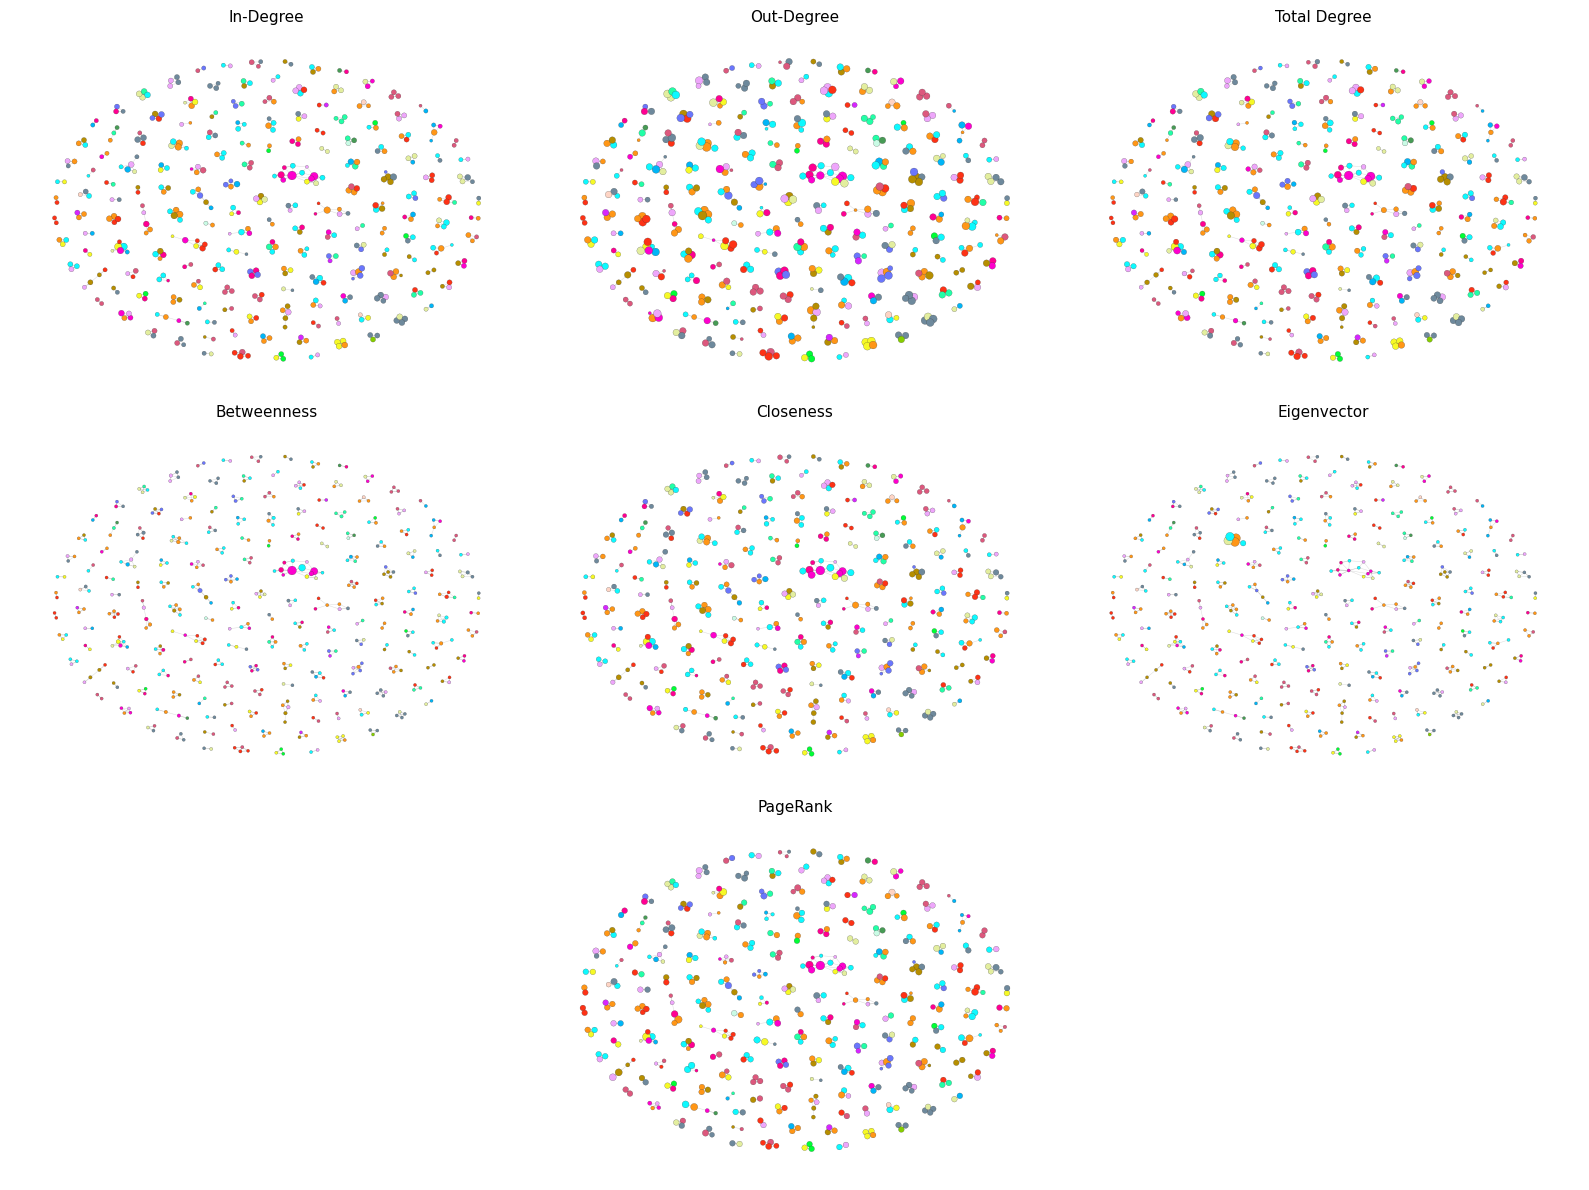

In [13]:
def compute_centralities(G, seed=99):
    centralities = {}

    centralities["In-Degree"] = dict(G.in_degree()) if isinstance(G, nx.DiGraph) else dict(G.degree())
    centralities["Out-Degree"] = dict(G.out_degree()) if isinstance(G, nx.DiGraph) else dict(G.degree())
    centralities["Total Degree"] = dict(G.degree())

    centralities["Betweenness"] = nx.betweenness_centrality(G, normalized=True)
    centralities["Closeness"] = nx.closeness_centrality(G)

    try:
        ev = nx.eigenvector_centrality(G, weight=None, max_iter=5000, tol=1e-8)
    except nx.PowerIterationFailedConvergence:
        ev = nx.eigenvector_centrality_numpy(G, weight=None)
    centralities["Eigenvector"] = ev

    centralities["PageRank"] = nx.pagerank(G, alpha=0.85, weight=None)

    return centralities

def _scale_sizes(values, base=6.0, span=22.0, fallback=10.0):
    v = np.asarray(values, dtype=float)
    if v.size == 0:
        return v
    mn, mx = float(np.nanmin(v)), float(np.nanmax(v))
    if not np.isfinite(mn) or not np.isfinite(mx) or (mx - mn) == 0:
        return np.full_like(v, fallback, dtype=float)
    return base + span * (v - mn) / (mx - mn)

def plot_centrality_on_graph_buttons(G, centrality_map, color_map, title_prefix="Centrality", max_nodes=999, seed=99):
    G_viz = pick_viz_subgraph(G, max_nodes=max_nodes, seed=seed)
    pos = nx.spring_layout(G_viz, seed=seed, k=0.60, iterations=120, scale=2.5)

    node_list = list(G_viz.nodes())
    x = np.array([pos[n][0] for n in node_list])
    y = np.array([pos[n][1] for n in node_list])

    in_deg = dict(G_viz.in_degree()) if isinstance(G_viz, nx.DiGraph) else dict(G_viz.degree())
    out_deg = dict(G_viz.out_degree()) if isinstance(G_viz, nx.DiGraph) else dict(G_viz.degree())
    tot_deg = dict(G_viz.degree())

    genres = pd.Series([G_viz.nodes[n].get("genre", "Other") for n in node_list]).fillna("Other")
    unique_genres = sorted(genres.unique().tolist())

    xe, ye = [], []
    edges_list = list(G_viz.edges())
    for u, v in edges_list:
        xe += [pos[u][0], pos[v][0], None]
        ye += [pos[u][1], pos[v][1], None]

    edge_trace = go.Scatter(
        x=xe, y=ye,
        mode="lines",
        line=dict(width=0.6, color="#888"),
        hoverinfo="skip",
        name="Edges"
    )

    fig = go.Figure()
    fig.add_trace(edge_trace)

    trace_meta = []
    for g in unique_genres:
        idx = (genres.values == g)
        trace_meta.append((g, idx))
        fig.add_trace(
            go.Scatter(
                x=x[idx],
                y=y[idx],
                mode="markers",
                name=g,
                marker=dict(size=np.full(int(idx.sum()), 10.0), color=color_map.get(g, "#666666"), line=dict(width=0.4)),
                text=[""] * int(idx.sum()),
                hoverinfo="text",
            )
        )

    metric_names = list(centrality_map.keys())
    per_metric_sizes = {}
    per_metric_texts = {}

    for m in metric_names:
        scores_all = np.array([centrality_map[m].get(n, 0.0) for n in node_list], dtype=float)
        sizes_all = _scale_sizes(scores_all, base=6.0, span=25.0, fallback=10.0)

        texts_all = []
        for n, sc in zip(node_list, scores_all):
            texts_all.append(
                f"ID: {n}"
                f"<br>title: {G_viz.nodes[n].get('title','')}"
                f"<br>genre: {G_viz.nodes[n].get('genre','')}"
                f"<br>in-degree: {in_deg.get(n,0)}"
                f"<br>out-degree: {out_deg.get(n,0)}"
                f"<br>total-degree: {tot_deg.get(n,0)}"
                f"<br>{m}: {float(sc):.6f}"
            )

        sizes_by_trace = [None]
        texts_by_trace = [None]
        for _, idx in trace_meta:
            sizes_by_trace.append(sizes_all[idx].tolist())
            texts_by_trace.append(np.array(texts_all, dtype=object)[idx].tolist())

        per_metric_sizes[m] = sizes_by_trace
        per_metric_texts[m] = texts_by_trace

    buttons = [
        dict(
            label=m,
            method="update",
            args=[
                {"marker.size": per_metric_sizes[m], "text": per_metric_texts[m]},
                {"title": f"{title_prefix}<br><span style='font-size:12px'>(metric={m})</span>"}
            ],
        )
        for m in metric_names
    ]

    first = metric_names[0]
    for i in range(1, len(fig.data)):
        fig.data[i].marker.size = per_metric_sizes[first][i]
        fig.data[i].text = per_metric_texts[first][i]

    fig.update_layout(
        title=dict(
            text=f"{title_prefix}<br><span style='font-size:12px'>(metric={first})</span>",
            x=0.5,
            y=0.97,
            xanchor="center",
            yanchor="top",
            pad=dict(t=10, b=28),
        ),
        height=680,
        margin=dict(l=10, r=10, t=100, b=10),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        legend=dict(title="Genre", itemsizing="constant"),
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.99,
                y=1.07,
                xanchor="right",
                yanchor="top",
                showactive=True,
                pad=dict(t=6, r=6, b=6, l=6),
                buttons=buttons,
            )
        ],
    )

    return fig

def plot_static_centrality_grid(
    G,
    centrality_map,
    color_map,
    grid_metrics,
    pagerank_key="PageRank",
    max_nodes=999,
    seed=99,
    figsize=(16, 12),
    node_size_base=5.0,
    node_size_span=35.0,
    node_size_fallback=25.0,
):
    G_viz = pick_viz_subgraph(G, max_nodes=max_nodes, seed=seed)
    pos = nx.spring_layout(G_viz, seed=seed, k=0.60, iterations=120, scale=2.5)
    node_list = list(G_viz.nodes())

    genres = pd.Series([G_viz.nodes[n].get("genre", "Other") for n in node_list]).fillna("Other")
    node_colors = [color_map.get(g, "#666666") for g in genres.values]

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(3, 3, figure=fig)

    axes = [fig.add_subplot(gs[r, c]) for r in range(3) for c in range(3)]
    for ax in axes:
        ax.set_axis_off()

    def _draw(ax, metric_name):
        scores = np.array([centrality_map[metric_name].get(n, 0.0) for n in node_list], dtype=float)
        sizes = _scale_sizes(
            scores,
            base=node_size_base,
            span=node_size_span,
            fallback=node_size_fallback,
        )
        nx.draw_networkx_edges(G_viz, pos, ax=ax, width=0.35, alpha=0.30, edge_color="#888888", arrows=False)
        nx.draw_networkx_nodes(
            G_viz, pos, ax=ax,
            node_size=sizes,
            node_color=node_colors,
            linewidths=0.15,
            edgecolors="#333333",
        )
        ax.set_title(metric_name, fontsize=11)
        ax.set_axis_off()

    for i, m in enumerate(grid_metrics[:6]):
        _draw(axes[i], m)

    if pagerank_key in centrality_map:
        _draw(axes[7], pagerank_key)

    plt.tight_layout()
    return fig

centrality_map = compute_centralities(G, seed=99)

grid_metrics = ["In-Degree", "Out-Degree", "Total Degree", "Betweenness", "Closeness", "Eigenvector"]
fig_grid = plot_static_centrality_grid(
    G,
    centrality_map=centrality_map,
    color_map=color_map,
    grid_metrics=grid_metrics,
    pagerank_key="PageRank",
    max_nodes=999,
    seed=99,
)
plt.show()

In [14]:
fig_interactive = plot_centrality_on_graph_buttons(
    G,
    centrality_map=centrality_map,
    color_map=color_map,
    title_prefix="Interactive Network Visualization",
    max_nodes=999,
    seed=99,
)
fig_interactive.show()

### *Detailed Interactive Graph*

In [15]:
# print("GENERATING CENTRALITY VISUALIZATIONS")
# print("=" * 70)

# # Visualizations
# plot_centrality_on_graph(G, in_degree, "In-Degree Centrality", color_map_full)
# plot_centrality_on_graph(G, out_degree, "Out-Degree Centrality", color_map_full)
# plot_centrality_on_graph(G, total_degree, "Total Degree Centrality", color_map_full)
# plot_centrality_on_graph(G, betweenness_centrality, "Betweenness Centrality", color_map_full)
# plot_centrality_on_graph(G, closeness_centrality, "Closeness Centrality", color_map_full)
# plot_centrality_on_graph(G, eigenvector_centrality, "Eigenvector Centrality", color_map_full)
# plot_centrality_on_graph(G, pagerank_centrality, "PageRank Centrality", color_map_full)

# ***-POIN ANALISIS-***

## **Kluster Produk (*Community Detection*)**

In [16]:
print("LOUVAIN COMMUNITY DETECTION (FULL GRAPH)")
print("=" * 80)

# =========================
# 0) Preconditions
# =========================
from collections import Counter

assert "WORK_DIR" in globals(), "WORK_DIR belum didefinisikan."
assert "G" in globals(), "G belum ada."
assert "nx" in globals() and "np" in globals() and "pd" in globals(), "nx/np/pd belum siap."
assert "go" in globals(), "plotly.graph_objects as go belum siap."

# ---- Robust Louvain import (fix community name-collision) ----
try:
    # Banyak kasus: python-louvain bisa diakses sebagai "community"
    import community as community_louvain
    # Jika ternyata ini paket "community" yang lain, best_partition tidak ada
    if not hasattr(community_louvain, "best_partition"):
        import community.community_louvain as community_louvain
except Exception as e:
    raise ImportError(
        "Louvain module tidak ditemukan / salah modul. Pastikan sudah install 'python-louvain' "
        "dan UNINSTALL paket 'community' yang bentrok. Jalankan:\n"
        "pip uninstall -y community\npip install -U python-louvain\n"
        "Lalu restart runtime/kernel."
    ) from e

# =========================
# 1) Louvain partition (must be undirected)
# =========================
G_u = G.to_undirected()
partition = community_louvain.best_partition(G_u, random_state=42)

# store back to original G
nx.set_node_attributes(G, partition, "community")

sizes = Counter(partition.values())
num_comms = len(sizes)

print(f"Total number of nodes: {G_u.number_of_nodes():,}")
print(f"Number of communities detected: {num_comms:,}")

# =========================
# 2) Full graph visualization (NO SUBGRAPH)
# =========================
seed = 42
pos = nx.spring_layout(G_u, seed=seed, k=0.60, iterations=120, scale=2.5)

node_list = list(G_u.nodes())
x = np.array([pos[n][0] for n in node_list])
y = np.array([pos[n][1] for n in node_list])

tot_deg = dict(G.degree())  # total degree (works for DiGraph too)
deg_raw = np.array([tot_deg.get(n, 0) for n in node_list], dtype=float)

node_sizes = (
    6 + 18 * (deg_raw - deg_raw.min()) / (deg_raw.max() - deg_raw.min() + 1e-9)
    if deg_raw.max() > deg_raw.min()
    else np.full_like(deg_raw, 10.0)
)

comms = pd.Series([partition.get(n, -1) for n in node_list])
uniq = sorted(comms.unique().tolist())

# Color palette (no px dependency)
palette = ["#CC2727", "#CC5E27", "#CC9527", "#CCCC27", "#95CC27", "#5ECC27", "#27CC27", "#27CC5E",
           "#27CC95", "#27CCCC", "#2795CC", "#275ECC", "#2727CC", "#5E27CC", "#9527CC", "#CC27CC",
           "#CC2795", "#CC275E", "#E05353", "#E08253", "#E0B153", "#E0E053", "#B1E053", "#82E053",
           "#53E053", "#53E082", "#53E0B1", "#53E0E0", "#53B1E0", "#5382E0", "#5353E0", "#8253E0",
           "#B153E0", "#E053E0", "#E053B1", "#E05382", "#F58787", "#F5AB87", "#F5D087", "#F5F587"]

comm_color = {c: palette[i % len(palette)] for i, c in enumerate(uniq)}

hover = [
    f"ID: {n}"
    f"<br>title: {G.nodes[n].get('title','')}"
    f"<br>genre: {G.nodes[n].get('genre','Other') or 'Other'}"
    f"<br>community: {c}"
    f"<br>total-degree: {tot_deg.get(n, 0)}"
    for n, c in zip(node_list, comms)
]

# edges (undirected for cleaner lines)
xe, ye = [], []
for u, v in G_u.edges():
    xe += [pos[u][0], pos[v][0], None]
    ye += [pos[u][1], pos[v][1], None]

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=xe, y=ye, mode="lines",
        line=dict(width=0.6, color="#888"),
        hoverinfo="skip",
        name="Edges",
    )
)

# node traces per community
hover_arr = np.array(hover, dtype=object)
for c in uniq:
    mask = (comms.values == c)
    fig.add_trace(
        go.Scatter(
            x=x[mask], y=y[mask],
            mode="markers",
            name=f"Community {c}",
            marker=dict(size=node_sizes[mask], color=comm_color.get(c, "#666666"), line=dict(width=0.4)),
            text=hover_arr[mask],
            hoverinfo="text",
        )
    )

fig.update_layout(
    title=f"Interactive Network Visualization — Louvain Communities (nodes={G_u.number_of_nodes():,})",
    height=650,
    margin=dict(l=10, r=10, t=70, b=10),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    legend=dict(title="Community", itemsizing="constant"),
)
fig.show()

# =========================
# 3) Edge-level Louvain report
# =========================
src_csv = f"{WORK_DIR}/amazon0302_DVD_optimized.csv"
df_edges = pd.read_csv(src_csv)

assert "ID" in df_edges.columns and "ID_cp" in df_edges.columns, \
    "Kolom ID / ID_cp tidak ditemukan di amazon0302_DVD_optimized.csv"

df_edges["community"] = df_edges["ID"].map(partition).fillna(-1).astype(int)

cols = df_edges.columns.tolist()
cols.insert(0, cols.pop(cols.index("community")))
df_edges = df_edges[cols]

out_csv = f"{WORK_DIR}/report_community_detection.csv"
df_edges.to_csv(out_csv, index=False)

print("\nEDGE REPORT SAVED")
print("-" * 80)
print(f"Source : {src_csv}")
print(f"Output : {out_csv}")

# sort for display only
df_edges_sorted = df_edges.sort_values("community", ascending=True).reset_index(drop=True)

if "display" in globals():
    display(df_edges_sorted.head(10))
else:
    print(df_edges_sorted.head(10).to_string(index=False))

LOUVAIN COMMUNITY DETECTION (FULL GRAPH)
Total number of nodes: 503
Number of communities detected: 162



EDGE REPORT SAVED
--------------------------------------------------------------------------------
Source : /content/amazon_work/amazon0302_DVD_optimized.csv
Output : /content/amazon_work/report_community_detection.csv
 community   ID                                 title                      genre  ID_cp                              title_cp                   genre_cp
         0 1627   Richard Strauss - Concerto for Horn Musicals & Performing Arts   1640     I Love Lucy - Season One (Vol. 3)                 Television
         0 1640     I Love Lucy - Season One (Vol. 3)                 Television   1627   Richard Strauss - Concerto for Horn Musicals & Performing Arts
         1 1632 Dragon Ball Z - Babidi - Battle Royal              Kids & Family   1631                        Arabian Nights         Action & Adventure
         1 1631                        Arabian Nights         Action & Adventure   1632 Dragon Ball Z - Babidi - Battle Royal              Kids & Family
         2 4026

In [17]:
print("COMMUNITY STATISTICS (SUMMARY TABLE)")
print("=" * 80)

assert "WORK_DIR" in globals()
assert "G" in globals()
assert "partition" in globals(), "partition belum tersedia (jalankan Block 1 dulu)."
assert "pd" in globals() and "nx" in globals()

# total degree (for DiGraph = in+out)
deg_total = dict(G.degree())

rows = []
# community -> members list
comm_to_members = {}
for n, c in partition.items():
    comm_to_members.setdefault(c, []).append(n)

for c, members in comm_to_members.items():
    members_sorted = sorted(members)  # stable output
    nNode = len(members_sorted)

    genres = []
    for n in members_sorted:
        g = G.nodes[n].get("genre", "Other")
        if g is None or (isinstance(g, str) and g.strip() == ""):
            g = "Other"
        genres.append(g)
    nGenre = len(set(genres))

    # Best node by total degree (tie-break: smallest ID string repr)
    best = max(
        members_sorted,
        key=lambda n: (deg_total.get(n, 0), str(n))
    )
    bn_title = G.nodes[best].get("title", "N/A")
    bn_deg = int(deg_total.get(best, 0))

    rows.append({
        "Community": int(c),
        "nNode": int(nNode),
        "nGenre": int(nGenre),
        "BestNode_ID": best,
        "BN_Title": bn_title,
        "BN_Degree": bn_deg,
        "Members": ",".join(map(str, members_sorted))
    })

df_comm = pd.DataFrame(rows).sort_values(["nNode", "nGenre"], ascending=[False, False]).reset_index(drop=True)

out_summary = f"{WORK_DIR}/report_community_summary.csv"
df_comm.to_csv(out_summary, index=False)

print(f"Saved: {out_summary}")

# show head (no data_table import)
if "display" in globals():
    display(df_comm.head(20))
else:
    print(df_comm.head(10).to_string(index=False))

COMMUNITY STATISTICS (SUMMARY TABLE)
Saved: /content/amazon_work/report_community_summary.csv
 Community  nNode  nGenre  BestNode_ID                                               BN_Title  BN_Degree                                                                                    Members
        56     13       6       261584                         Hollywood Screen Tests, Take 1         11 261582,261583,261584,261587,261588,261590,261593,261594,261595,261598,261599,261605,261606
        73      6       6       114191 Listen to Britain and Other Films by Humphrey Jennings          8                                                  114187,114189,114190,114191,143564,182209
        13      6       5        12617                        Burial Ground - Night of Terror          4                                                       12615,12617,12618,15740,81590,236161
        12      6       3       240155                    Cinema Europe - The Other Hollywood          5                  

## **Produk Berpengaruh**

In [18]:
def _colpick(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def attach_node_attrs_from_df(G, df):
    if df is None or not isinstance(df, pd.DataFrame) or df.empty:
        return

    id_col = _colpick(df, ["ID", "id", "src", "source", "from"])
    cp_col = _colpick(df, ["ID_cp", "id_cp", "dst", "target", "to"])
    title_col = _colpick(df, ["Title", "title"])
    genre_col = _colpick(df, ["Genre", "genre"])
    if (title_col is None) and (genre_col is None):
        return

    node_cols = [c for c in [id_col, cp_col] if c is not None]
    attr_cols = [c for c in [title_col, genre_col] if c is not None]
    tmp = df[node_cols + attr_cols].copy()

    for nc in node_cols:
        tmp[nc] = pd.to_numeric(tmp[nc], errors="ignore")

    def _apply_attr(node_col, attr_col, attr_name):
        if node_col is None or attr_col is None:
            return
        s = tmp[[node_col, attr_col]].dropna(subset=[node_col, attr_col]).drop_duplicates()
        s = s.rename(columns={node_col: "node", attr_col: attr_name})
        m = dict(zip(s["node"], s[attr_name].astype(str)))
        for n, v in m.items():
            if n in G.nodes and attr_name not in G.nodes[n]:
                G.nodes[n][attr_name] = v

    _apply_attr(id_col, title_col, "title")
    _apply_attr(cp_col, title_col, "title")
    _apply_attr(id_col, genre_col, "genre")
    _apply_attr(cp_col, genre_col, "genre")

def compute_kcore(G):
    Gu = G.to_undirected() if isinstance(G, nx.DiGraph) else G
    return nx.core_number(Gu)

def safe_pagerank(G, alpha=0.85):
    try:
        return nx.pagerank(G, alpha=alpha, weight=None, max_iter=1000, tol=1e-8)
    except Exception:
        return nx.pagerank(G, alpha=alpha, weight=None)

df_final = globals().get("df_final", None)
attach_node_attrs_from_df(G, df_final)

comm_path = os.path.join(WORK_DIR, "report_community_detection.csv")
if not os.path.exists(comm_path):
    raise FileNotFoundError(f"File report komunitas tidak ditemukan di: {comm_path}")

df_comm = pd.read_csv(comm_path)
idc = _colpick(df_comm, ["ID", "id"])
cc = _colpick(df_comm, ["Community", "community"])
if idc is None or cc is None:
    raise ValueError("Kolom ID/Community tidak ditemukan di report_community_detection.csv")

comm_map = dict(zip(df_comm[idc], df_comm[cc]))

core = compute_kcore(G)
pr = safe_pagerank(G, alpha=0.85)

is_dir = isinstance(G, nx.DiGraph)
deg_tot = dict(G.degree())
deg_in = dict(G.in_degree()) if is_dir else dict(G.degree())
deg_out = dict(G.out_degree()) if is_dir else dict(G.degree())

rows = []
for n in G.nodes():
    g = G.nodes[n].get("genre", "Other")
    g = g if (g not in (None, "", "nan")) else "Other"
    rows.append({
        "ID": n,
        "Title": G.nodes[n].get("title", "N/A"),
        "Genre": g,
        "Community": comm_map.get(n, -1),
        "Core": int(core.get(n, 0)),
        "PageRank": float(pr.get(n, 0.0)),
        "InDegree": int(deg_in.get(n, 0)),
        "OutDegree": int(deg_out.get(n, 0)),
        "TotalDegree": int(deg_tot.get(n, 0)),
    })

df_influential = pd.DataFrame(rows)
out_path = os.path.join(WORK_DIR, "report_nodes_influential.csv")
df_influential.to_csv(out_path, index=False)

df_top_pagerank = df_influential.sort_values(
    ["PageRank", "TotalDegree", "Core", "ID"],
    ascending=[False, False, False, True]
).head(10).reset_index(drop=True)

print("INFLUENTIAL NODES ANALYSIS")
print("=" * 70)
print(f"Saved: {out_path}")

print("\nTOP-10 INFLUENTIAL (PageRank DESC)")
print("=" * 70)
try:
    display(df_top_pagerank)
except NameError:
    print(df_top_pagerank.to_string(index=False))

INFLUENTIAL NODES ANALYSIS
Saved: /content/amazon_work/report_nodes_influential.csv

TOP-10 INFLUENTIAL (PageRank DESC)


/tmp/ipython-input-3016841150.py:23: FutureWarning:

errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead



,ID,Title,Genre,Community,Core,PageRank,InDegree,OutDegree,TotalDegree
0,261584,"Hollywood Screen Tests, Take 1",Classics,56,2,0.005768,8,3,11
1,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,73,3,0.004531,5,3,8
2,261588,Flash Gordon - The Deadly Ray from Mars,Science Fiction & Fantasy,56,2,0.004079,4,3,7
3,247061,Why Do They Say Love When They Mean Sex?,Drama,147,2,0.003954,2,2,4
4,132754,The Blue Angel,Drama,81,3,0.003805,4,3,7
5,1677,Robert Louis Stevenson's St. Ives,Drama,2,2,0.003743,3,2,5
6,103734,The Men Who Killed Kennedy,Documentary,61,3,0.003632,3,2,5
7,48094,The Rose,Drama,30,1,0.003631,2,1,3
8,215420,The Butcher,Mystery & Suspense,127,1,0.003631,2,1,3
9,256873,Tempest 3000,Action & Adventure,157,2,0.003569,3,3,6


## **Genre Berpengaruh**

In [19]:
def _g(G, n):
    v = G.nodes[n].get("genre", "Other") if n in G.nodes else "Other"
    return v if v not in (None, "", "nan") else "Other"

def _safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def build_genre_influence_table(G):
    is_dir = isinstance(G, nx.DiGraph)
    nodes = list(G.nodes())

    deg_in = dict(G.in_degree()) if is_dir else dict(G.degree())
    deg_out = dict(G.out_degree()) if is_dir else dict(G.degree())
    deg_tot = dict(G.degree())

    node_genre = {n: _g(G, n) for n in nodes}

    agg = {}
    for n in nodes:
        g = node_genre[n]
        if g not in agg:
            agg[g] = {"Qty": 0, "InDeg": 0, "OutDeg": 0, "TotalDeg": 0, "SelfDeg": 0}
        agg[g]["Qty"] += 1
        agg[g]["InDeg"] += int(deg_in.get(n, 0))
        agg[g]["OutDeg"] += int(deg_out.get(n, 0))
        agg[g]["TotalDeg"] += int(deg_tot.get(n, 0))

    for u, v in G.edges():
        gu, gv = node_genre.get(u, "Other"), node_genre.get(v, "Other")
        if gu == gv:
            agg[gu]["SelfDeg"] += 1

    rows = []
    for g, d in agg.items():
        out_edges = d["OutDeg"]
        self_edges = d["SelfDeg"]
        cross_out = out_edges - self_edges
        rows.append({
            "Genre": g,
            "Qty": int(d["Qty"]),
            "InDeg": int(d["InDeg"]),
            "OutDeg": int(d["OutDeg"]),
            "TotalDeg": int(d["TotalDeg"]),
            "SelfDeg": int(self_edges),
            "CrossOut": int(cross_out),
            "SelfRate": round(_safe_div(self_edges, out_edges), 6),
            "CrossOutRate": round(_safe_div(cross_out, out_edges), 6),
        })

    df = pd.DataFrame(rows).sort_values(["TotalDeg"], ascending=[False]).reset_index(drop=True)
    return df

df_genre_influence = build_genre_influence_table(G)
out_path = os.path.join(WORK_DIR, "report_genre_influence.csv")
df_genre_influence.to_csv(out_path, index=False)

print("GENRE INFLUENCE ANALYSIS")
print("=" * 70)
print(f"Saved: {out_path}")

try:
    display(df_genre_influence.head(15))
except NameError:
    print(df_genre_influence.head(15).to_string(index=False))

GENRE INFLUENCE ANALYSIS
Saved: /content/amazon_work/report_genre_influence.csv


,Genre,Qty,InDeg,OutDeg,TotalDeg,SelfDeg,CrossOut,SelfRate,CrossOutRate
0,Drama,73,149,140,289,23,117,0.164286,0.835714
1,Comedy,69,127,119,246,15,104,0.126050,0.873950
2,Music Video & Concerts,46,81,84,165,25,59,0.297619,0.702381
3,Action & Adventure,39,70,73,143,18,55,0.246575,0.753425
4,Mystery & Suspense,35,64,65,129,10,55,0.153846,0.846154
5,Horror,36,60,67,127,6,61,0.089552,0.910448
6,Kids & Family,40,65,61,126,23,38,0.377049,0.622951
7,Documentary,23,48,46,94,6,40,0.130435,0.869565
8,Television,24,43,48,91,10,38,0.208333,0.791667
9,Science Fiction & Fantasy,23,40,44,84,5,39,0.113636,0.886364


## **Pola Rekomendasi**

In [20]:
def pick_viz_subgraph(G, max_nodes=999, seed=99):
    nodes = list(G.nodes())
    if len(nodes) <= max_nodes:
        return G
    rng = np.random.default_rng(seed)
    sampled = rng.choice(nodes, size=max_nodes, replace=False).tolist()
    return G.subgraph(sampled).copy()

def compute_kcore(G):
    Gu = G.to_undirected() if isinstance(G, nx.DiGraph) else G
    core = nx.core_number(Gu)
    df_core_dist = (
        pd.Series(core, name="core_number")
        .value_counts()
        .sort_index()
        .rename_axis("core_number")
        .reset_index(name="count")
    )
    return core, df_core_dist

def plot_kcore_shells(G, core_number, title, max_nodes=999, seed=99, max_arrows=250):
    G_viz = pick_viz_subgraph(G, max_nodes=max_nodes, seed=seed)
    pos = nx.spring_layout(G_viz, seed=seed, k=0.60, iterations=120, scale=2.5)

    nodes = list(G_viz.nodes())
    x = np.array([pos[n][0] for n in nodes])
    y = np.array([pos[n][1] for n in nodes])

    deg = dict(G_viz.degree())
    core_vals = np.array([core_number.get(n, 0) for n in nodes], dtype=float)
    sizes = _scale_sizes([deg.get(n, 0) for n in nodes], base=6.0, span=22.0, fallback=10.0)

    xe, ye = [], []
    edges = list(G_viz.edges())
    for u, v in edges:
        xe += [pos[u][0], pos[v][0], None]
        ye += [pos[u][1], pos[v][1], None]

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=xe, y=ye, mode="lines", line=dict(width=0.6, color="#888"), hoverinfo="skip", name="Edges"))

    hover = [
        f"ID: {n}"
        f"<br>title: {G_viz.nodes[n].get('title','')}"
        f"<br>genre: {G_viz.nodes[n].get('genre','Other')}"
        f"<br>core: {int(core_number.get(n, 0))}"
        f"<br>degree: {int(deg.get(n, 0))}"
        for n in nodes
    ]

    fig.add_trace(
        go.Scatter(
            x=x, y=y, mode="markers", name="Nodes",
            text=hover, hoverinfo="text",
            marker=dict(
                size=sizes, color=core_vals, colorscale="Viridis",
                showscale=True, colorbar=dict(title="k-core"),
                line=dict(width=0.35, color="#333"),
            ),
        )
    )

    annotations = []
    if isinstance(G_viz, nx.DiGraph):
        for u, v in edges[:max_arrows]:
            annotations.append(
                dict(
                    x=pos[v][0], y=pos[v][1], ax=pos[u][0], ay=pos[u][1],
                    xref="x", yref="y", axref="x", ayref="y",
                    showarrow=True, arrowhead=2, arrowsize=1, arrowwidth=1,
                    opacity=0.65, text="",
                )
            )

    fig.update_layout(
        title=title, height=650,
        margin=dict(l=10, r=10, t=70, b=10),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        annotations=annotations,
    )
    return fig

def build_spreader_report(G, core_number, top_n=10):
    is_dir = isinstance(G, nx.DiGraph)
    out_deg = dict(G.out_degree()) if is_dir else dict(G.degree())
    in_deg  = dict(G.in_degree())  if is_dir else dict(G.degree())
    tot_deg = dict(G.degree())

    nodes = list(G.nodes())
    df = pd.DataFrame({
        "ID": nodes,
        "Core": [core_number.get(n, 0) for n in nodes],
        "OutDegree": [int(out_deg.get(n, 0)) for n in nodes],
        "InDegree": [int(in_deg.get(n, 0)) for n in nodes],
        "TotalDegree": [int(tot_deg.get(n, 0)) for n in nodes],
    }).sort_values(["Core", "OutDegree", "TotalDegree", "ID"], ascending=[False, False, False, True]).head(top_n)

    def _title(n): return G.nodes[n].get("title", "N/A")
    def _genre(n): return G.nodes[n].get("genre", "Other") or "Other"

    df.insert(1, "Title", df["ID"].map(_title))
    df.insert(2, "Genre", df["ID"].map(_genre))
    return df

core_number, df_core_dist = compute_kcore(G)
df_top_spreaders = build_spreader_report(G, core_number, top_n=10)

fig = plot_kcore_shells(
    G,
    core_number,
    title=f"Network with k-core shells (color=k-core, size=degree) | nodes={G.number_of_nodes():,}, edges={G.number_of_edges():,}",
    max_nodes=999,
    seed=99,
)
fig.show()

print("\nRECOMMENDATION PATTERN ANALYSIS")
print("=" * 70)

print("\nTOP SPREADER CANDIDATES (High k-core + High degree)")
print("=" * 70)
try:
    display(df_top_spreaders)
except NameError:
    print(df_top_spreaders.to_string(index=False))

df_top_spreaders.to_csv(f"{WORK_DIR}/report_nodes_k-core.csv", index=False)

print(f"\nSaved: report_nodes_k-core.csv")

print("\nK-CORE DISTRIBUTION")
print("=" * 70)
try:
    display(df_core_dist)
except NameError:
    print(df_core_dist.to_string(index=False))


RECOMMENDATION PATTERN ANALYSIS

TOP SPREADER CANDIDATES (High k-core + High degree)


,ID,Title,Genre,Core,OutDegree,InDegree,TotalDegree
303,167608,Crimes of Passion,Mystery & Suspense,3,4,4,8
478,261352,Taps,Drama,3,4,4,8
206,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,3,3,5,8
183,109198,Jack the Ripper,Mystery & Suspense,3,3,4,7
234,132754,The Blue Angel,Drama,3,3,4,7
208,143564,Jeremiah Johnson,Classics,3,3,4,7
301,167606,Tender Mercies,Drama,3,3,4,7
477,261351,The Princess and the Barrio Boy,Drama,3,3,4,7
18,9275,"The Speeches Collection, Vol. 1",Documentary,3,3,3,6
19,9276,The Adventures of Sherlock Holmes (Boxed Set C...,Mystery & Suspense,3,3,3,6



Saved: report_nodes_k-core.csv

K-CORE DISTRIBUTION


,core_number,count
0,1,126
1,2,277
2,3,100


In [21]:
path = os.path.join(WORK_DIR, "report_nodes_k-core.csv")

if not os.path.exists(path):
    raise FileNotFoundError(f"File not found: {path}. Make sure BC1 saved it via df_top_spreaders.to_csv(f'{WORK_DIR}/report_nodes_k-core.csv', index=False)")

df = pd.read_csv(path)

print("TOP SPREADER CANDIDATES (Sorted by OutDegree DESC)")
print("=" * 70)
df_out = df.sort_values(["OutDegree", "Core", "TotalDegree", "ID"], ascending=[False, False, False, True])
try:
    display(df_out)
except NameError:
    print(df_out.to_string(index=False))

print("\nTOP SPREADER CANDIDATES (Sorted by InDegree DESC)")
print("=" * 70)
df_in = df.sort_values(["InDegree", "Core", "TotalDegree", "ID"], ascending=[False, False, False, True])
try:
    display(df_in)
except NameError:
    print(df_in.to_string(index=False))

TOP SPREADER CANDIDATES (Sorted by OutDegree DESC)


,ID,Title,Genre,Core,OutDegree,InDegree,TotalDegree
0,167608,Crimes of Passion,Mystery & Suspense,3,4,4,8
1,261352,Taps,Drama,3,4,4,8
2,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,3,3,5,8
3,109198,Jack the Ripper,Mystery & Suspense,3,3,4,7
4,132754,The Blue Angel,Drama,3,3,4,7
5,143564,Jeremiah Johnson,Classics,3,3,4,7
6,167606,Tender Mercies,Drama,3,3,4,7
7,261351,The Princess and the Barrio Boy,Drama,3,3,4,7
8,9275,"The Speeches Collection, Vol. 1",Documentary,3,3,3,6
9,9276,The Adventures of Sherlock Holmes (Boxed Set C...,Mystery & Suspense,3,3,3,6



TOP SPREADER CANDIDATES (Sorted by InDegree DESC)


,ID,Title,Genre,Core,OutDegree,InDegree,TotalDegree
2,114191,Listen to Britain and Other Films by Humphrey ...,Documentary,3,3,5,8
0,167608,Crimes of Passion,Mystery & Suspense,3,4,4,8
1,261352,Taps,Drama,3,4,4,8
3,109198,Jack the Ripper,Mystery & Suspense,3,3,4,7
4,132754,The Blue Angel,Drama,3,3,4,7
5,143564,Jeremiah Johnson,Classics,3,3,4,7
6,167606,Tender Mercies,Drama,3,3,4,7
7,261351,The Princess and the Barrio Boy,Drama,3,3,4,7
8,9275,"The Speeches Collection, Vol. 1",Documentary,3,3,3,6
9,9276,The Adventures of Sherlock Holmes (Boxed Set C...,Mystery & Suspense,3,3,3,6


In [22]:
import pandas as pd
from collections import Counter
import networkx as nx

def _genre(G, n, genre_key="genre"):
    g = G.nodes[n].get(genre_key, "Other") if n in G.nodes else "Other"
    return g if g not in (None, "", "nan") else "Other"

def compute_genre_transitions(G, genre_key="genre", top_n=10):
    directed = Counter()
    for u, v in G.edges():
        directed[(_genre(G, u, genre_key), _genre(G, v, genre_key))] += 1

    df_dir = (
        pd.DataFrame([(a, b, c) for (a, b), c in directed.items()], columns=["Genre_From", "Genre_To", "Count"])
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    undirected = Counter()
    Gu = G.to_undirected() if isinstance(G, nx.DiGraph) else G
    for u, v in Gu.edges():
        a, b = _genre(G, u, genre_key), _genre(G, v, genre_key)
        if a <= b:
            undirected[(a, b)] += 1
        else:
            undirected[(b, a)] += 1

    df_undir = (
        pd.DataFrame([(a, b, c) for (a, b), c in undirected.items()], columns=["Genre_A", "Genre_B", "Count"])
        .sort_values("Count", ascending=False)
        .reset_index(drop=True)
    )

    return df_dir.head(top_n), df_undir.head(top_n)

df_dir_top, df_undir_top = compute_genre_transitions(G, genre_key="genre", top_n=10)

print("TOP GENRE ➡️ GENRE TRANSITIONS (DIRECTED, exact count)")
print("=" * 70)
try:
    display(df_dir_top)
except NameError:
    print(df_dir_top.to_string(index=False))

print("\nTOP GENRE ↔️ GENRE CONNECTIONS (UNDIRECTED, exact count)")
print("=" * 70)
try:
    display(df_undir_top)
except NameError:
    print(df_undir_top.to_string(index=False))

TOP GENRE ➡️ GENRE TRANSITIONS (DIRECTED, exact count)


,Genre_From,Genre_To,Count
0,Comedy,Drama,29
1,Drama,Comedy,28
2,Music Video & Concerts,Music Video & Concerts,25
3,Kids & Family,Kids & Family,23
4,Drama,Drama,23
5,Action & Adventure,Action & Adventure,18
6,Comedy,Comedy,15
7,Horror,Comedy,13
8,Drama,Mystery & Suspense,13
9,Mystery & Suspense,Drama,12



TOP GENRE ↔️ GENRE CONNECTIONS (UNDIRECTED, exact count)


,Genre_A,Genre_B,Count
0,Comedy,Drama,32
1,Drama,Mystery & Suspense,15
2,Action & Adventure,Drama,14
3,Comedy,Horror,14
4,Music Video & Concerts,Music Video & Concerts,14
5,Drama,Drama,13
6,Horror,Music Video & Concerts,12
7,Kids & Family,Kids & Family,12
8,Comedy,Mystery & Suspense,11
9,Drama,Kids & Family,10


# ***-INFORMATION DIFFUSION-***

In [24]:
# BLOCK 1: Genre–Genre Heatmap (Directed vs Undirected) + CSV report

import os
import numpy as np
import pandas as pd
from collections import defaultdict
import plotly.graph_objects as go
from plotly.subplots import make_subplots

assert "G" in globals(), "Graph G belum ada di environment."
assert "WORK_DIR" in globals(), "WORK_DIR belum didefinisikan."

def build_genre_heatmap_and_report(G, top_k=10, colorscale="Viridis"):
    WORK_DIR = globals()["WORK_DIR"]
    os.makedirs(WORK_DIR, exist_ok=True)

    if G.number_of_nodes() == 0:
        print("Graph kosong, tidak bisa membuat heatmap.")
        return

    # -------------------------
    # 1) Genre tiap node (missing -> 'Other')
    # -------------------------
    def _genre(n):
        g = G.nodes[n].get("genre", None)
        if g is None or (isinstance(g, str) and g.strip() == ""):
            return "Other"
        return g

    node_genre = {n: _genre(n) for n in G.nodes()}
    H = G.to_undirected() if G.is_directed() else G

    # -------------------------
    # 2) Tetapkan label genre (Top-K + Other)
    #    Ranking berdasarkan "edge incidence" (seberapa sering muncul di edges)
    # -------------------------
    counts = defaultdict(int)
    for u, v in G.edges():
        counts[node_genre[u]] += 1
        counts[node_genre[v]] += 1

    ranked = sorted(
        [(g, c) for g, c in counts.items() if g != "Other"],
        key=lambda kv: kv[1],
        reverse=True,
    )
    top_genres = [g for g, _ in ranked[:top_k]]
    labels = top_genres + ["Other"]
    idx = {g: i for i, g in enumerate(labels)}
    n = len(labels)
    top_set = set(top_genres)

    def _map(g):
        return g if g in top_set else "Other"

    # -------------------------
    # 3) Matriks directed (FROM -> TO) & undirected (Genre–Genre)
    # -------------------------
    mat_dir = np.zeros((n, n), dtype=int)
    for u, v in G.edges():
        gu = _map(node_genre[u])
        gv = _map(node_genre[v])
        mat_dir[idx[gu], idx[gv]] += 1

    mat_und = np.zeros((n, n), dtype=int)
    for u, v in H.edges():
        gu = _map(node_genre.get(u, "Other"))
        gv = _map(node_genre.get(v, "Other"))
        a, b = sorted([gu, gv])
        ia, ib = idx[a], idx[b]
        mat_und[ia, ib] += 1
        if ia != ib:
            mat_und[ib, ia] += 1

    # -------------------------
    # 4) Heatmap Plotly (dua panel)
    # -------------------------
    zmax = int(max(mat_dir.max(), mat_und.max()))

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=[
            f"Directed (Top-{top_k} + Other)",
            f"Undirected (Top-{top_k} + Other)",
        ],
        horizontal_spacing=0.18,
        column_widths=[0.5, 0.5],
    )

    # Directed
    fig.add_trace(
        go.Heatmap(
            z=mat_dir,
            x=labels,
            y=labels,
            colorscale=colorscale,
            zmin=0,
            zmax=zmax,
            colorbar=dict(title="# edges", len=0.85),
            hovertemplate=(
                "FROM = %{y}<br>"
                "TO   = %{x}<br>"
                "count = %{z:,}"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=1,
    )

    # Undirected
    fig.add_trace(
        go.Heatmap(
            z=mat_und,
            x=labels,
            y=labels,
            colorscale=colorscale,
            zmin=0,
            zmax=zmax,
            showscale=False,
            hovertemplate=(
                "Genre A = %{y}<br>"
                "Genre B = %{x}<br>"
                "count = %{z:,}"
                "<extra></extra>"
            ),
        ),
        row=1,
        col=2,
    )

    # Overlay angka COUNT di setiap kotak
    def _overlay_counts(mat, col, font_size=11):
        xs, ys, texts = [], [], []
        for i, ylab in enumerate(labels):
            for j, xlab in enumerate(labels):
                c = int(mat[i, j])
                xs.append(xlab)
                ys.append(ylab)
                texts.append(f"{c:,}")
        fig.add_trace(
            go.Scatter(
                x=xs,
                y=ys,
                mode="text",
                text=texts,
                textposition="middle center",
                textfont=dict(family="Arial", size=font_size, color="white"),
                hoverinfo="skip",
                showlegend=False,
            ),
            row=1,
            col=col,
        )

    _overlay_counts(mat_dir, col=1)
    _overlay_counts(mat_und, col=2)

    fig.update_layout(
        title=(
            "Genre–Genre Co-purchase Heatmap "
            "(Exact Count) — Directed vs Undirected"
        ),
        title_x=0.5,
        height=760,
        margin=dict(l=95, r=40, t=95, b=60),
    )
    fig.update_xaxes(title="TO Genre", side="bottom", row=1, col=1)
    fig.update_xaxes(title="Genre", side="bottom", row=1, col=2)
    fig.update_yaxes(title="FROM Genre", autorange="reversed", row=1, col=1)
    fig.update_yaxes(title="Genre", autorange="reversed", row=1, col=2)

    fig.show()

    # -------------------------
    # 5) Build & save CSV: report_genre_correlation.csv
    # -------------------------
    rows = []
    for i, g_from in enumerate(labels):
        for j, g_to in enumerate(labels):
            c_dir = int(mat_dir[i, j])
            c_und = int(mat_und[i, j])
            if c_dir > 0 or c_und > 0:
                rows.append((g_from, g_to, c_dir, c_und))

    df_report = pd.DataFrame(
        rows, columns=["FROM", "TO", "COUNT_DIR", "COUNT_UND"]
    ).sort_values(
        ["COUNT_DIR", "COUNT_UND"], ascending=False
    ).reset_index(drop=True)

    csv_path = os.path.join(WORK_DIR, "report_genre_correlation.csv")
    df_report.to_csv(csv_path, index=False)
    print(f"Saved CSV: {csv_path}")

# Jalankan:
build_genre_heatmap_and_report(G, top_k=10, colorscale="Viridis")

Saved CSV: /content/amazon_work/report_genre_correlation.csv


/tmp/ipython-input-261259062.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



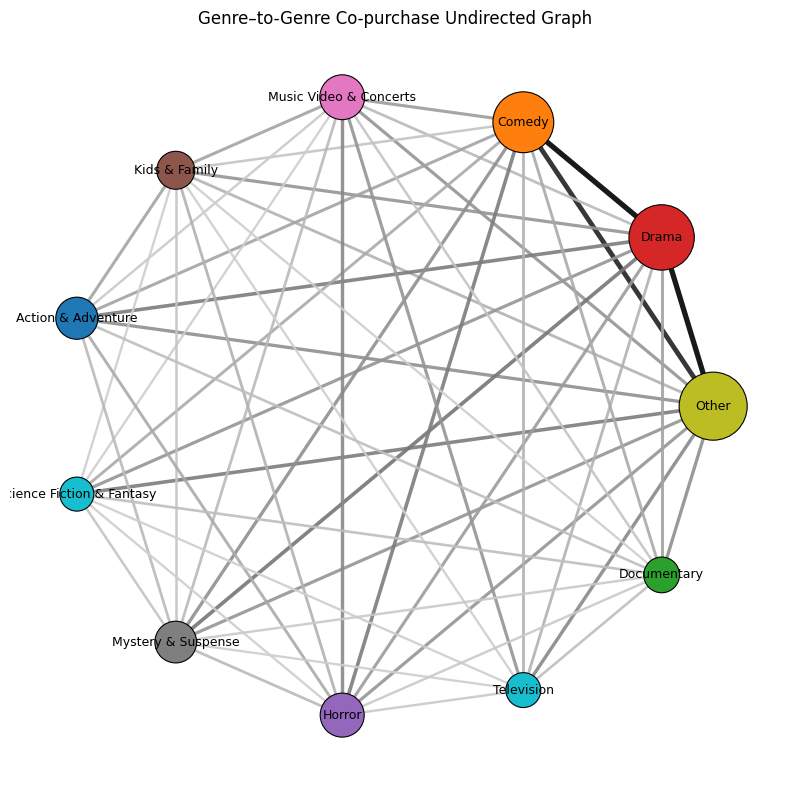

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ================================
# 1. Posisi node: circular layout
# ================================
pos = nx.circular_layout(G_genre_ud)

genres = sorted(G_genre_ud.nodes())

# ================================
# 2. Node colors: pakai colormap bawaan (tab10)
# ================================
# Setiap genre dapat warna beda, loop kalau >10
cmap_nodes = plt.cm.get_cmap("tab10", len(genres))
node_colors = [cmap_nodes(i) for i in range(len(genres))]

# Node size proporsional terhadap total weight undirected
total_und = {}
for g in G_genre_ud.nodes():
    w_sum = 0
    for _, nbr_dict in G_genre_ud[g].items():
        w_sum += nbr_dict.get("weight_und", 0)
    total_und[g] = w_sum

deg_vals = np.array([max(total_und[g], 1) for g in genres], dtype=float)
min_deg, max_deg = deg_vals.min(), deg_vals.max()
deg_range = max(max_deg - min_deg, 1.0)

node_sizes = []
for g in genres:
    val = max(total_und[g], 1)
    norm = (val - min_deg) / deg_range
    size = 600 + 1800 * norm   # 600..2400
    node_sizes.append(size)

# ================================
# 3. Edge weights → grayscale yang LEBIH GELAP
# ================================
# Jangan gambar self-loop
edges_nonloop = [
    (u, v, data)
    for u, v, data in G_genre_ud.edges(data=True)
    if u != v
]

weights = [data.get("weight_und", 0) for _, _, data in edges_nonloop]
if len(weights) == 0:
    print("No non-self-loop edges found.")
    weights = [0]

w_min, w_max = min(weights), max(weights)
w_range = max(w_max - w_min, 1.0)

# Normalisasi 0..1
w_norm = [(w - w_min) / w_range for w in weights]
# Naikkan baseline supaya yang kecil tidak terlalu pucat:
# 0..1 → 0.3..1.0
w_norm_darker = [0.3 + 0.7 * n for n in w_norm]

plt.figure(figsize=(8, 8))

edges = [(u, v) for u, v, _ in edges_nonloop]
edge_collection = nx.draw_networkx_edges(
    G_genre_ud,
    pos,
    edgelist=edges,
    edge_color=w_norm_darker,
    edge_cmap=plt.cm.Greys,    # grayscale
    edge_vmin=0.0,
    edge_vmax=1.0,
    width=[0.8 + 3.0 * n for n in w_norm_darker],  # sedikit lebih tebal
    alpha=0.9
)

# ================================
# 4. Draw nodes + labels
# ================================
nx.draw_networkx_nodes(
    G_genre_ud,
    pos,
    nodelist=genres,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=0.8
)

nx.draw_networkx_labels(
    G_genre_ud,
    pos,
    labels={g: g for g in genres},
    font_size=9
)

plt.title("Genre–to-Genre Co-purchase Undirected Graph")
plt.axis("off")
plt.tight_layout()
plt.show()


In [40]:

assert "G_genre_ud" in globals(), "G_genre_ud belum ada."

genres = sorted(G_genre_ud.nodes())

# 1) Layout: circular (biar rapi dan konsisten)
pos = nx.circular_layout(G_genre_ud)

# 2) Hitung total COUNT_UND per genre + neighbor weights
total_und = {}
neighbor_weights = defaultdict(lambda: defaultdict(int))

for g in G_genre_ud.nodes():
    w_sum = 0
    for nbr, data in G_genre_ud[g].items():
        w = data.get("weight_und", 0)
        w_sum += w
        neighbor_weights[g][nbr] += w
    total_und[g] = w_sum

# 3) NODE COLORS: pakai palette resmi Plotly (warna-warni, ignore comm_color)
# palette = px.colors.qualitative.Set3  # 12 warna; looping kalau genre > 12
palette = px.colors.qualitative.G10  # 12 warna; looping kalau genre > 12

node_colors = [palette[i % len(palette)] for i, _ in enumerate(genres)]


# 4) NODE SIZE: proporsional ke total COUNT_UND
deg_vals = np.array([max(total_und[g], 1) for g in genres], dtype=float)
min_deg, max_deg = deg_vals.min(), deg_vals.max()
deg_range = max(max_deg - min_deg, 1.0)

node_sizes = []
for g in genres:
    val = max(total_und[g], 1)
    norm = (val - min_deg) / deg_range
    size = 14 + 30 * norm   # 14..44 → kalau mau lebih besar, ubah di sini
    node_sizes.append(size)

# 5) EDGES: grayscale, tanpa self-loop
edges_nonloop = [
    (u, v, data)
    for u, v, data in G_genre_ud.edges(data=True)
    if u != v
]

weights = [data.get("weight_und", 0) for _, _, data in edges_nonloop]
if not weights:
    weights = [0]

w_min, w_max = min(weights), max(weights)
w_range = max(w_max - w_min, 1.0)

# Normalisasi 0..1 → lalu geser jadi 0.3..1.0 biar semua cukup gelap/kontras
w_norm = [(w - w_min) / w_range for w in weights]
w_norm_darker = [0.3 + 0.7 * n for n in w_norm]

edge_traces = []
for (u, v, data), wn, w in zip(edges_nonloop, w_norm_darker, weights):
    x0, y0 = pos[u]
    x1, y1 = pos[v]

    # grayscale: wn besar → lebih gelap
    shade = int(255 * (1 - wn))
    color = f"rgb({shade},{shade},{shade})"

    edge_traces.append(
        go.Scatter(
            x=[x0, x1],
            y=[y0, y1],
            mode="lines",
            line=dict(
                width=1.0 + 3.0 * wn,  # kalau mau edges lebih/kurang tebal, ubah di sini
                color=color,
            ),
            hoverinfo="text",
            hovertext=(
                f"{u} – {v}<br>"
                f"COUNT_UND: {w}"
            ),
            showlegend=False,
        )
    )

# 6) NODE TRACE: hover text tanpa prefix "With"
node_x = []
node_y = []
node_text = []

for g in genres:
    x, y = pos[g]
    node_x.append(x)
    node_y.append(y)

    neigh_map = neighbor_weights[g]
    lines = [f"Genre: {g}"]
    # contoh: "Action & Adventure: 123" bukan "With Action & Adventure: ..."
    for tgt in sorted(genres):
        w = neigh_map.get(tgt, 0)
        if w > 0:
            lines.append(f"{tgt}: {w}")
    lines.append(f"Total COUNT_UND: {total_und.get(g, 0)}")
    node_text.append("<br>".join(lines))

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode="markers+text",
    name="Genres",
    text=[g for g in genres],
    textposition="top center",
    hoverinfo="text",
    hovertext=node_text,
    marker=dict(
        size=node_sizes,
        color=node_colors,                 # <— NODE WARNA-WARNI di sini
        opacity=0.95,
        line=dict(width=0.8, color="rgba(30,30,30,0.8)"),
    ),
    textfont=dict(size=11),
)

# 7) Build figure
fig = go.Figure()

for tr in edge_traces:
    fig.add_trace(tr)
fig.add_trace(node_trace)

fig.update_layout(
    title=(
        "Genre–to-Genre Co-purchase Undirected Graph"
    ),
    title_x=0.5,
    showlegend=False,
    hovermode="closest",
    margin=dict(l=20, r=20, t=90, b=20),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    height=800,   # <— UBAH HEIGHT DI SINI KALAU MAU LEBIH TINGGI/RENDAH
)

fig.show()


=== IC Scenario X ===
Seed X (start) = ['Drama']
Total infected per step:
Step 0: infected = 1
Step 1: infected = 7
Step 2: infected = 11


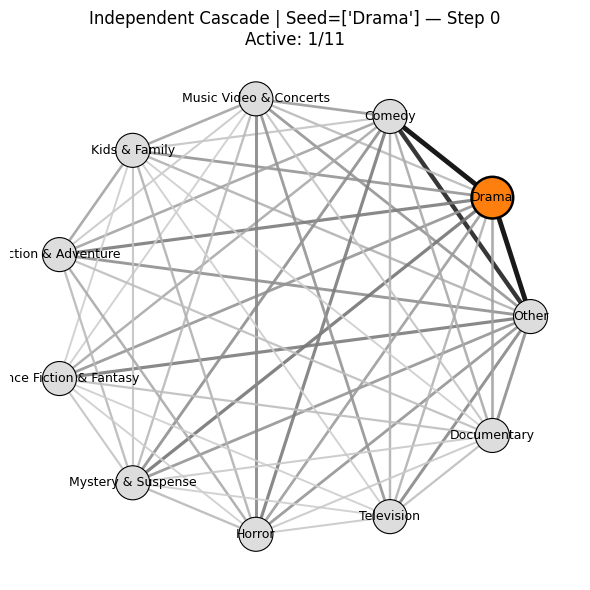

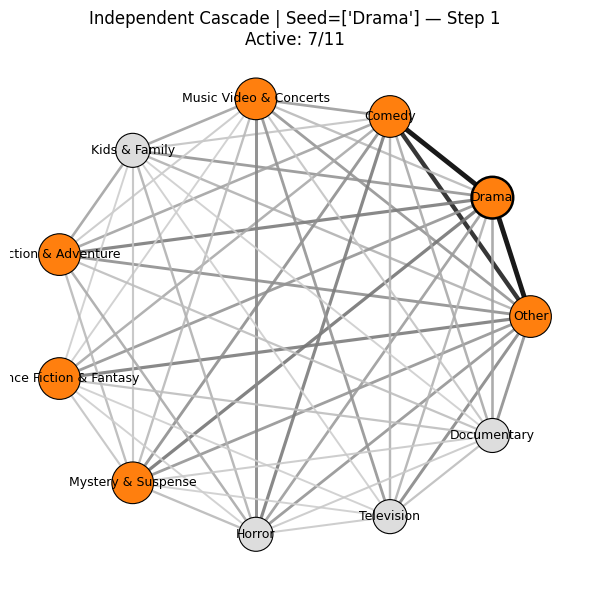

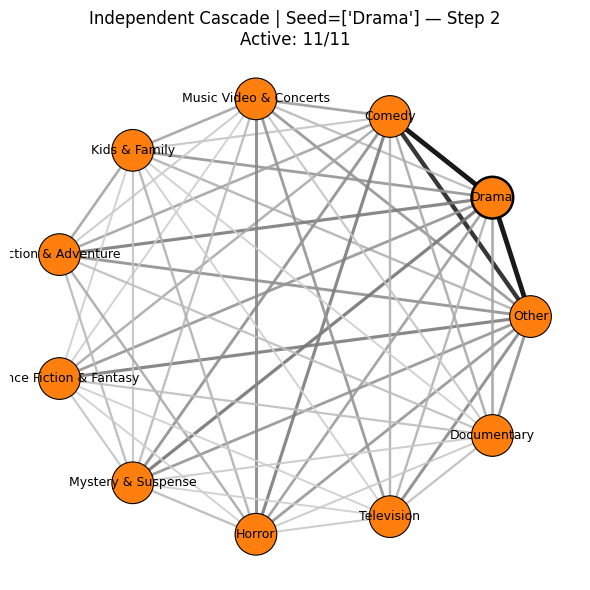

'/content/amazon_work/ic_diffusion/ic_seedX.gif'

In [74]:
import os
import random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import imageio
import networkx as nx
from IPython.display import Image, display

assert "G_genre_ud" in globals(), "G_genre_ud belum ada."
assert "WORK_DIR" in globals(), "WORK_DIR belum didefinisikan."

# --- IC: edge probability from weight_und ---
def build_edge_probabilities_ic(G, weight_attr="weight_und", p_min=0.10, p_max=0.90):
    weights = [data.get(weight_attr, 1) for _, _, data in G.edges(data=True)]
    if not weights:
        raise ValueError("Graf tidak punya edge; IC tidak bisa dijalankan.")
    w_min, w_max = min(weights), max(weights)
    w_range = max(w_max - w_min, 1.0)

    edge_p = {}
    for u, v, data in G.edges(data=True):
        w = data.get(weight_attr, 1)
        norm = (w - w_min) / w_range
        p = p_min + norm * (p_max - p_min)
        edge_p[tuple(sorted((u, v)))] = float(p)
    return edge_p


# --- IC simulation (tracks targets + source per activation) ---
def simulate_ic(G, seeds, edge_p, max_steps=15, rng_seed=42):
    rng = random.Random(rng_seed)

    seeds = list(seeds)
    valid_seeds = [s for s in seeds if s in G.nodes()]
    if not valid_seeds:
        raise ValueError(f"Tidak ada seed yang valid. Seeds={seeds}")

    state = {n: False for n in G.nodes()}
    for s in valid_seeds:
        state[s] = True

    frontier = set(valid_seeds)
    history = [deepcopy(state)]
    activations = [{"new_active": sorted(valid_seeds), "parent": {s: None for s in valid_seeds}}]

    for _ in range(1, max_steps + 1):
        new_active = set()
        parent = {}

        for u in frontier:
            for v in G.neighbors(u):
                if state[v]:
                    continue
                p = float(edge_p.get(tuple(sorted((u, v))), 0.0))
                if rng.random() <= p:
                    if v not in new_active:
                        new_active.add(v)
                        parent[v] = u

        if not new_active:
            break

        for v in new_active:
            state[v] = True

        frontier = new_active
        history.append(deepcopy(state))
        activations.append({"new_active": sorted(new_active), "parent": parent})

    return history, activations


# --- Matplotlib frame capture (fixed for newer Matplotlib) ---
def _fig_to_rgb_array(fig):
    fig.canvas.draw()
    rgba = np.asarray(fig.canvas.buffer_rgba())
    return rgba[..., :3].copy()

def _edges_grayscale_from_probs(G, edge_p, baseline=0.30):
    edges = [(u, v) for u, v in G.edges() if u != v]
    if not edges:
        return [], []
    probs = [float(edge_p.get(tuple(sorted((u, v))), 0.0)) for u, v in edges]
    p_min, p_max = min(probs), max(probs)
    p_range = max(p_max - p_min, 1e-12)
    p_norm = [(p - p_min) / p_range for p in probs]
    p_norm_darker = [baseline + (1.0 - baseline) * x for x in p_norm]
    return edges, p_norm_darker


# --- Show 1 step frame (for “frame-by-frame dulu”) ---
def draw_ic_step(G, pos, state, step_idx, seeds, title_prefix="IC", edge_p=None, newly_active=None):
    fig, ax = plt.subplots(figsize=(6, 6))

    seed_set = set(seeds)
    node_colors = ["tab:orange" if state[n] else "#dddddd" for n in G.nodes()]
    node_sizes  = [900 if state[n] else 600 for n in G.nodes()]
    node_lw     = [1.8 if n in seed_set else 0.8 for n in G.nodes()]

    if edge_p is not None:
        edges, wn = _edges_grayscale_from_probs(G, edge_p, baseline=0.30)
        if edges:
            nx.draw_networkx_edges(
                G, pos,
                edgelist=edges,
                edge_color=wn,
                edge_cmap=plt.cm.Greys,
                edge_vmin=0.0, edge_vmax=1.0,
                width=[0.5 + 3.0 * x for x in wn],
                alpha=0.9,
                ax=ax,
            )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=list(G.nodes()),
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="black",
        linewidths=node_lw,
        ax=ax,
    )

    nx.draw_networkx_labels(G, pos, labels={g: g for g in G.nodes()}, font_size=9, ax=ax)

    active_count = sum(1 for v in state.values() if v)
    total_nodes = G.number_of_nodes()

    if newly_active is None:
        newly_active = []
    ax.set_title(
      f"{title_prefix} — Step {step_idx}\n"
      f"Active: {active_count}/{total_nodes}"
    )

    ax.axis("off")
    fig.tight_layout()
    plt.show()


# --- Build GIF after showing frames ---
def make_gif_ic(G, pos, history, seeds, filename, duration=1.0, repeat_last=3, edge_p=None, title_prefix="IC", new_active_list=None):
    frames = []
    for step_idx, state in enumerate(history):
        fig, ax = plt.subplots(figsize=(6, 6))

        seed_set = set(seeds)
        node_colors = ["tab:orange" if state[n] else "#dddddd" for n in G.nodes()]
        node_sizes  = [900 if state[n] else 600 for n in G.nodes()]
        node_lw     = [1.8 if n in seed_set else 0.8 for n in G.nodes()]

        if edge_p is not None:
            edges, wn = _edges_grayscale_from_probs(G, edge_p, baseline=0.30)
            if edges:
                nx.draw_networkx_edges(
                    G, pos,
                    edgelist=edges,
                    edge_color=wn,
                    edge_cmap=plt.cm.Greys,
                    edge_vmin=0.0, edge_vmax=1.0,
                    width=[0.5 + 3.0 * x for x in wn],
                    alpha=0.9,
                    ax=ax,
                )

        nx.draw_networkx_nodes(
            G, pos,
            nodelist=list(G.nodes()),
            node_color=node_colors,
            node_size=node_sizes,
            edgecolors="black",
            linewidths=node_lw,
            ax=ax,
        )
        nx.draw_networkx_labels(G, pos, labels={g: g for g in G.nodes()}, font_size=9, ax=ax)

        active_count = sum(1 for v in state.values() if v)
        total_nodes = G.number_of_nodes()
        newly = (new_active_list[step_idx] if (new_active_list and step_idx < len(new_active_list)) else [])

        ax.set_title(
            f"{title_prefix} — Step {step_idx}\n"
            f"Active: {active_count}/{total_nodes}"
        )

        ax.axis("off")
        fig.tight_layout()

        frames.append(_fig_to_rgb_array(fig))
        plt.close(fig)

    for _ in range(repeat_last):
        frames.append(frames[-1])

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    imageio.mimsave(filename, frames, duration=duration, loop=0, fps=1)
    return filename


# ============================================================
# RUN (Genre Undirected IC) — show frames first, then GIF
# ============================================================

pos_genre = nx.circular_layout(G_genre_ud)
edge_p_ic = build_edge_probabilities_ic(G_genre_ud, weight_attr="weight_und", p_min=0.10, p_max=0.90)

ic_dir = os.path.join(WORK_DIR, "ic_diffusion")
os.makedirs(ic_dir, exist_ok=True)

# Scenario X (seed jelas + target tiap step)
seed_X = ["Drama"]
history_X, act_X = simulate_ic(G_genre_ud, seeds=seed_X, edge_p=edge_p_ic, max_steps=15, rng_seed=123)

print("=== IC Scenario X ===")
print(f"Seed X (start) = {seed_X}")
print("Total infected per step:")

for t, state in enumerate(history_X):
    infected = sum(1 for v in state.values() if v)
    print(f"Step {t}: infected = {infected}")

# Frame-by-frame dulu (sesuai referensi)
new_list_X = [info["new_active"] for info in act_X] + [[]] * max(0, len(history_X) - len(act_X))
for t, state in enumerate(history_X):
    draw_ic_step(
        G_genre_ud, pos_genre, state, t, seeds=seed_X,
        title_prefix=f"Independent Cascade | Seed={seed_X}",
        edge_p=edge_p_ic,
        newly_active=(new_list_X[t] if t < len(new_list_X) else [])
    )

# Baru GIF (durasi/FPS jangan diubah dari setting kamu — default di sini 1.0 sesuai kode kamu sebelumnya)
gif_X_path = os.path.join(ic_dir, "ic_seedX.gif")
make_gif_ic(
    G_genre_ud, pos_genre, history_X, seeds=seed_X,
    filename=gif_X_path,
    duration=1.0,      # BIARKAN sesuai setting kamu
    repeat_last=1,     # BIARKAN sesuai setting kamu
    edge_p=edge_p_ic,
    title_prefix=f"Independent Cascade | Seed={seed_X}",
    new_active_list=new_list_X
)

IC GIF (Seed X) saved at: /content/amazon_work/ic_diffusion/ic_seedX.gif


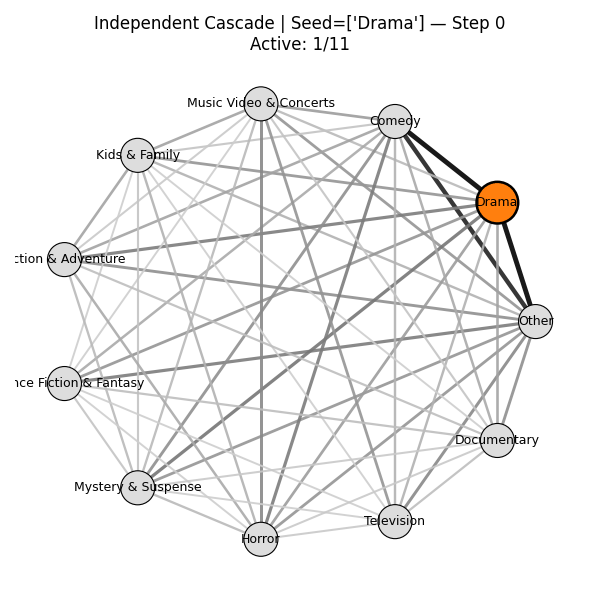

In [75]:
print("IC GIF (Seed X) saved at:", gif_X_path)
display(Image(gif_X_path))


=== IC Scenario Y ===
Seed Y (start) = ['Action & Adventure']
Total infected per step:
Step 0: infected = 1


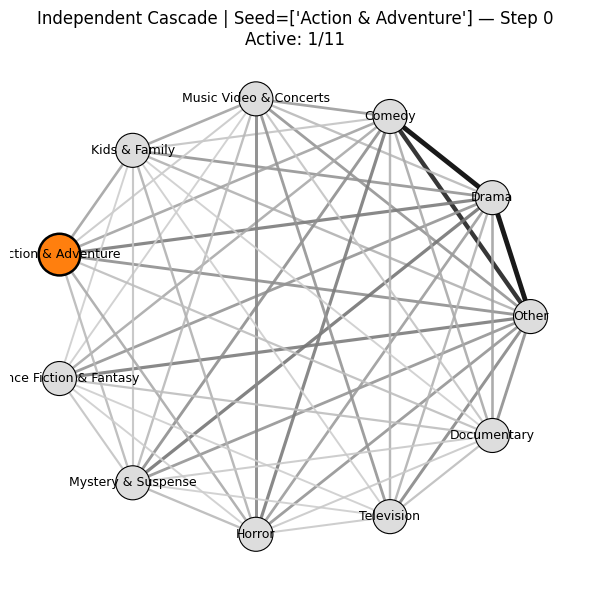

'/content/amazon_work/ic_diffusion/ic_seedY.gif'

In [76]:
# Scenario Y
seed_Y = ["Action & Adventure"]
history_Y, act_Y = simulate_ic(G_genre_ud, seeds=seed_Y, edge_p=edge_p_ic, max_steps=15, rng_seed=456)

print("\n=== IC Scenario Y ===")
print(f"Seed Y (start) = {seed_Y}")
print("Total infected per step:")

for t, state in enumerate(history_Y):
    infected = sum(1 for v in state.values() if v)
    print(f"Step {t}: infected = {infected}")


new_list_Y = [info["new_active"] for info in act_Y] + [[]] * max(0, len(history_Y) - len(act_Y))
for t, state in enumerate(history_Y):
    draw_ic_step(
        G_genre_ud, pos_genre, state, t, seeds=seed_Y,
        title_prefix=f"Independent Cascade | Seed={seed_Y}",
        edge_p=edge_p_ic,
    )

gif_Y_path = os.path.join(ic_dir, "ic_seedY.gif")
make_gif_ic(
    G_genre_ud, pos_genre, history_Y, seeds=seed_Y,
    filename=gif_Y_path,
    duration=1.0,      # BIARKAN sesuai setting kamu
    repeat_last=3,     # BIARKAN sesuai setting kamu
    edge_p=edge_p_ic,
    title_prefix=f"Independent Cascade | Seed={seed_Y}",
    new_active_list=new_list_Y
)

IC GIF (Seed Y) saved at: /content/amazon_work/ic_diffusion/ic_seedY.gif


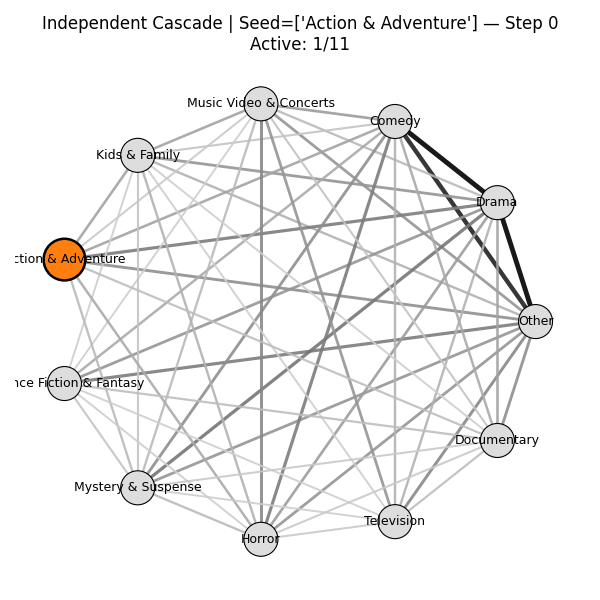

In [77]:
print("IC GIF (Seed Y) saved at:", gif_Y_path)
display(Image(gif_Y_path))